In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q timm albumentations imbalanced-learn

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    f1_score, cohen_kappa_score, brier_score_loss
)
from imblearn.over_sampling import RandomOverSampler
from scipy import stats
from itertools import cycle

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = 7

Using: cuda


In [4]:

import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from tqdm import tqdm

In [5]:

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000


!unzip -q skin-cancer-mnist-ham10000.zip -d HAM10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100%|███████████████████████████████████████| 5.20G/5.20G [00:24<00:00, 226MB/s]



In [6]:

df = pd.read_csv("HAM10000/HAM10000_metadata.csv")


label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['dx'])


img_path1 = 'HAM10000/HAM10000_images_part_1/'
img_path2 = 'HAM10000/HAM10000_images_part_2/'
all_img_paths = {os.path.splitext(f)[0]: os.path.join(img_path1, f)
                 if os.path.exists(os.path.join(img_path1, f))
                 else os.path.join(img_path2, f)
                 for f in os.listdir(img_path1) + os.listdir(img_path2)}
df['path'] = df['image_id'].map(all_img_paths)


print("Class distribution before balancing:")
print(df['dx'].value_counts())
print("\nNumeric label distribution:")
print(df['label'].value_counts())

Class distribution before balancing:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Numeric label distribution:
label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [7]:
# Apply oversampling to balance the dataset
ros = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = ros.fit_resample(df[['path']], df['label'])
df_balanced = pd.DataFrame(X_resampled)
df_balanced['label'] = y_resampled

print("Balanced class distribution:")
print(df_balanced['label'].value_counts())

# Split into training and validation sets
train_df, val_df = train_test_split(df_balanced, test_size=0.2,
                                   stratify=df_balanced['label'],
                                   random_state=SEED)

print(f"\nTraining set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")

Balanced class distribution:
label
2    6705
5    6705
3    6705
4    6705
6    6705
1    6705
0    6705
Name: count, dtype: int64

Training set: 37548 samples
Validation set: 9387 samples


In [8]:
# Custom dataset class
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df.loc[idx, 'path']).convert('RGB')
        image = np.array(image)
        label = self.df.loc[idx, 'label']
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label

# Define transformations
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.5),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Create datasets and dataloaders
train_dataset = SkinDataset(train_df, transform=train_transform)
val_dataset = SkinDataset(val_df, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_55/280942777.py:25: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.5),


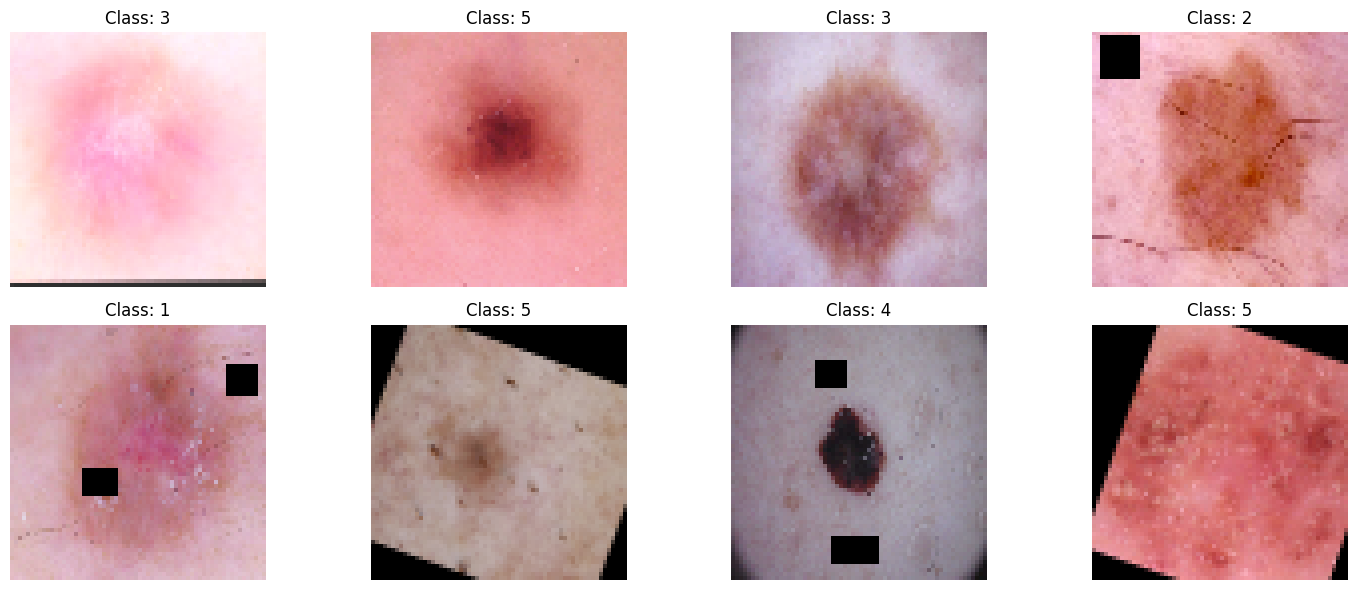

In [9]:
# Visualize some sample images
plt.figure(figsize=(15, 6))
for i in range(8):
    img, label = train_dataset[i]
    # Convert tensor to numpy for visualization
    img = img.permute(1, 2, 0).numpy() * 0.5 + 0.5  # Denormalize
    img = np.clip(img, 0, 1)

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# Define DCNN model
class DCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(DCNN, self).__init__()
        self.features = nn.Sequential(
            self.conv_block(3, 32),
            self.conv_block(32, 64),
            self.conv_block(64, 128),
            self.conv_block(128, 256)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256*4*4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = DCNN().to(device)
print(model)

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

DCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), s

In [11]:
# Define custom label smoothing loss
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=7, smoothing=0.1):
        super(LabelSmoothingLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes

    def forward(self, x, target):
        log_probs = F.log_softmax(x, dim=-1)
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(self.smoothing / (self.cls - 1))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

# Initialize loss, optimizer, scheduler and gradient scaler
criterion = LabelSmoothingLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_55/1954773474.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [12]:
# Training function
def train_one_epoch():
    model.train()
    running_loss = 0
    correct, total = 0, 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # Calculate training accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    return running_loss / len(train_loader), train_acc

# Evaluation function
def evaluate():
    model.eval()
    correct, total = 0, 0
    class_correct = [0] * 7
    class_total = [0] * 7

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Per-class accuracy
            for i in range(labels.size(0)):
                label = labels[i]
                class_correct[label] += (preds[i] == label).item()
                class_total[label] += 1

    # Calculate per-class accuracy
    class_acc = [100 * correct / max(1, total) for correct, total in zip(class_correct, class_total)]
    return 100 * correct / total, class_acc

In [13]:
# Training loop
best_acc = 0
train_losses, val_accs = [], []
epochs = 50

for epoch in range(1, epochs + 1):
    print(f"\n🌟 Epoch {epoch}/{epochs}")

    # Train
    loss, train_acc = train_one_epoch()
    train_losses.append(loss)
    print(f"📊 Loss: {loss:.4f} | Train Accuracy: {train_acc:.2f}%")

    # Evaluate
    val_acc, class_accs = evaluate()
    val_accs.append(val_acc)
    print(f"✅ Val Accuracy: {val_acc:.2f}%")

    # Log per-class accuracy
    for i, acc in enumerate(class_accs):
        print(f"Class {i} accuracy: {acc:.2f}%")

    # Learning rate scheduler
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"💾 Model saved with accuracy: {best_acc:.2f}%")

print(f"\n🔥 Best Accuracy: {best_acc:.2f}%")


🌟 Epoch 1/50


Training:   0%|          | 0/294 [00:00<?, ?it/s]/tmp/ipykernel_55/856930157.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 294/294 [01:53<00:00,  2.59it/s]


📊 Loss: 1.4007 | Train Accuracy: 52.95%


Evaluating: 100%|██████████| 74/74 [00:25<00:00,  2.85it/s]


✅ Val Accuracy: 65.48%
Class 0 accuracy: 34.23%
Class 1 accuracy: 51.83%
Class 2 accuracy: 59.88%
Class 3 accuracy: 78.45%
Class 4 accuracy: 65.18%
Class 5 accuracy: 69.80%
Class 6 accuracy: 99.03%
💾 Model saved with accuracy: 65.48%

🌟 Epoch 2/50


...

✅ Val Accuracy: 98.10%
Class 0 accuracy: 100.00%
Class 1 accuracy: 100.00%
Class 2 accuracy: 99.63%
Class 3 accuracy: 100.00%
Class 4 accuracy: 98.96%
Class 5 accuracy: 88.14%
Class 6 accuracy: 100.00%
💾 Model saved with accuracy: 98.10%

🌟 Epoch 50/50


Training: 100%|██████████| 294/294 [01:51<00:00,  2.64it/s]


📊 Loss: 0.5863 | Train Accuracy: 97.10%


Evaluating: 100%|██████████| 74/74 [00:25<00:00,  2.88it/s]

✅ Val Accuracy: 97.85%
Class 0 accuracy: 100.00%
Class 1 accuracy: 100.00%
Class 2 accuracy: 99.70%
Class 3 accuracy: 100.00%
Class 4 accuracy: 99.48%
Class 5 accuracy: 85.76%
Class 6 accuracy: 100.00%

🔥 Best Accuracy: 98.10%


NameError: name 'train_accs' is not defined

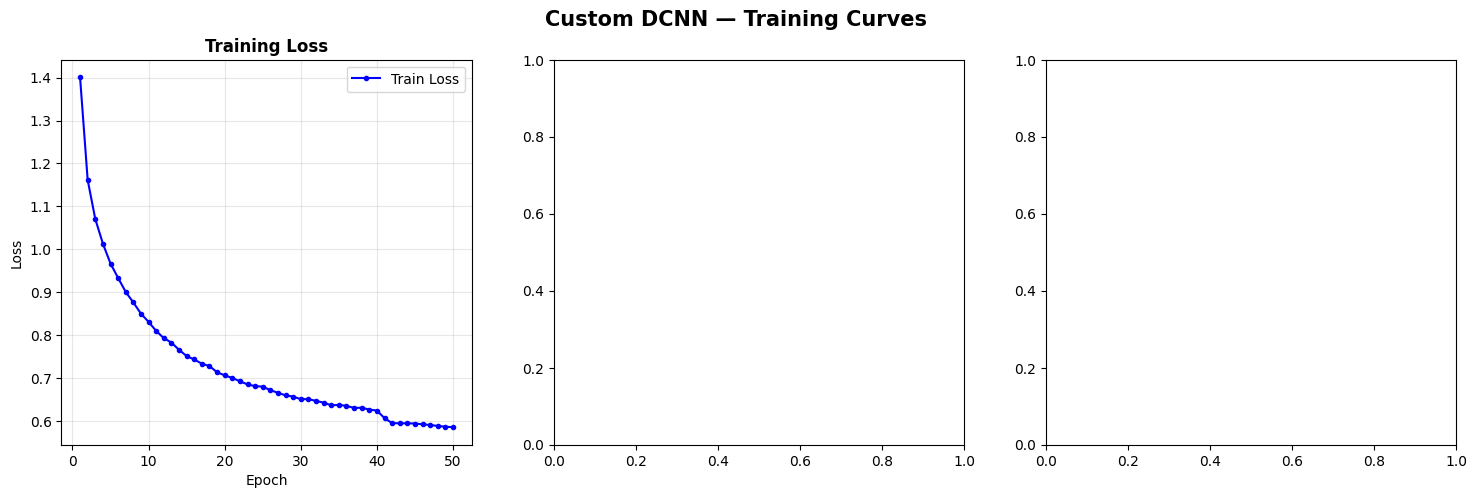

In [18]:
model.load_state_dict(torch.load('best_model.pth'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Custom DCNN — Training Curves', fontsize=15, fontweight='bold')

epoch_range = range(1, epochs + 1)

# Loss curve
axes[0].plot(epoch_range, train_losses, 'b-o', markersize=3, label='Train Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epoch_range, train_accs, 'g-o', markersize=3, label='Train Accuracy')
axes[1].plot(epoch_range, val_accs,   'r-o', markersize=3, label='Val Accuracy')
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(epoch_range, lr_history, 'm-o', markersize=3)
axes[2].set_title('Learning Rate Schedule', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_dcnn.png', dpi=150, bbox_inches='tight')
plt.show()

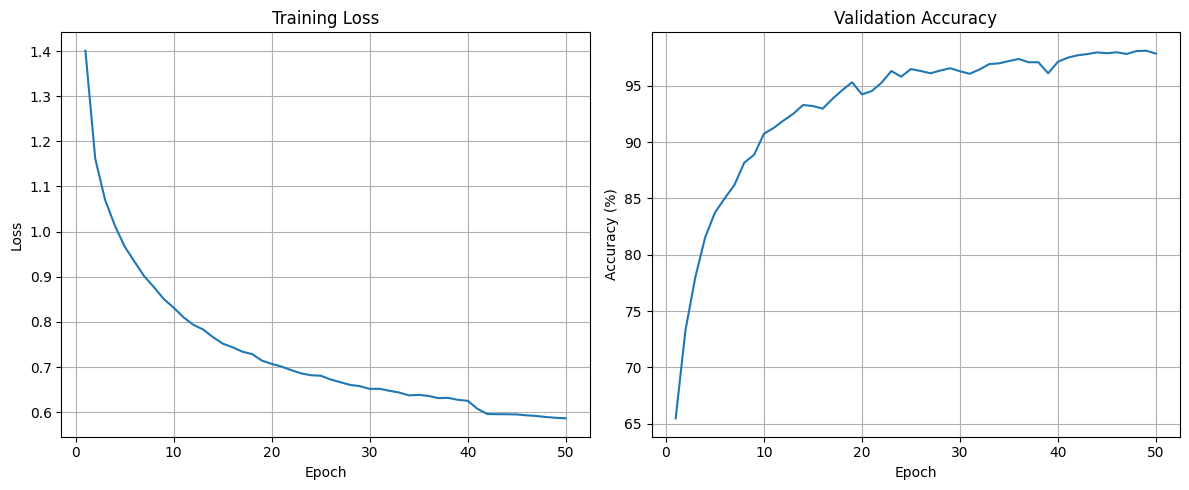

In [19]:
# Plot training progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_accs)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
!pip install seaborn

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [23]:
def get_preds(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

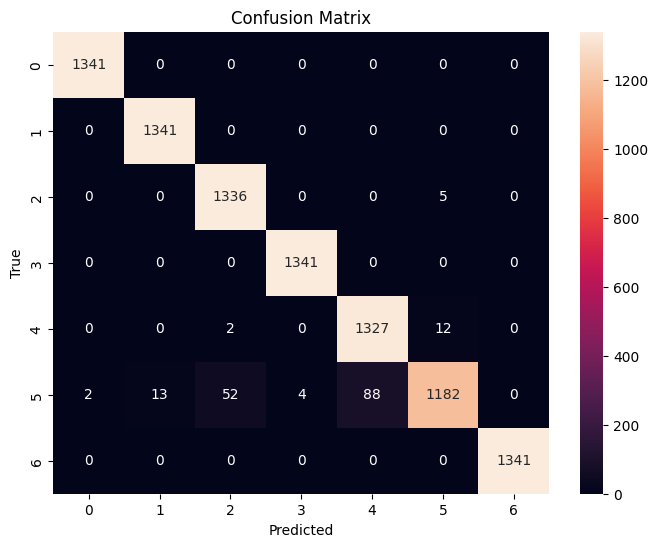

In [24]:
y_true, y_pred = get_preds(model, val_loader)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       0.99      1.00      1.00      1341
           2       0.96      1.00      0.98      1341
           3       1.00      1.00      1.00      1341
           4       0.94      0.99      0.96      1341
           5       0.99      0.88      0.93      1341
           6       1.00      1.00      1.00      1341

    accuracy                           0.98      9387
   macro avg       0.98      0.98      0.98      9387
weighted avg       0.98      0.98      0.98      9387



In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [30]:
def roc_multiclass(model, loader):

    model.eval()
    y_true = []
    y_score = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = torch.softmax(model(images),1)

            y_true.extend(labels.numpy())
            y_score.extend(outputs.cpu().numpy())

    y_true = label_binarize(y_true, classes=[0,1,2,3,4,5,6])
    y_score = np.array(y_score)

    for i in range(7):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} AUC={roc_auc:.2f}')

    plt.legend()
    plt.title("ROC Curve")
    plt.show()

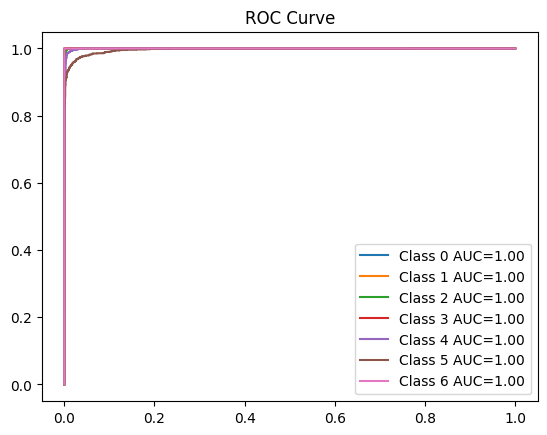

In [31]:
roc_multiclass(model, val_loader)

In [32]:
from sklearn.decomposition import PCA

In [33]:
def extract_features(model, loader):
    model.eval()
    feats = []
    labels = []

    with torch.no_grad():
        for images, lab in loader:
            images = images.to(device)
            x = model.features(images)
            x = torch.flatten(x,1)

            feats.append(x.cpu().numpy())
            labels.append(lab.numpy())

    return np.vstack(feats), np.hstack(labels)

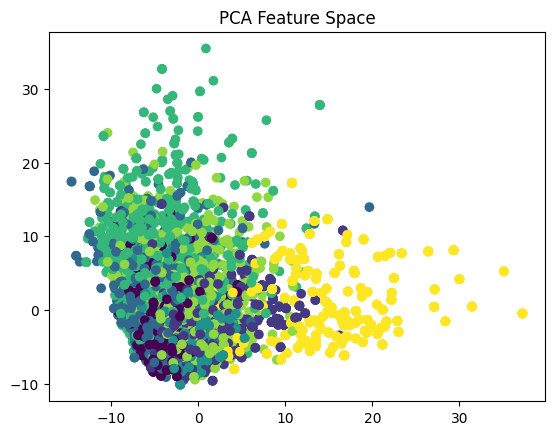

In [34]:
features, labels = extract_features(model, val_loader)

pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0], reduced[:,1], c=labels)
plt.title("PCA Feature Space")
plt.show()

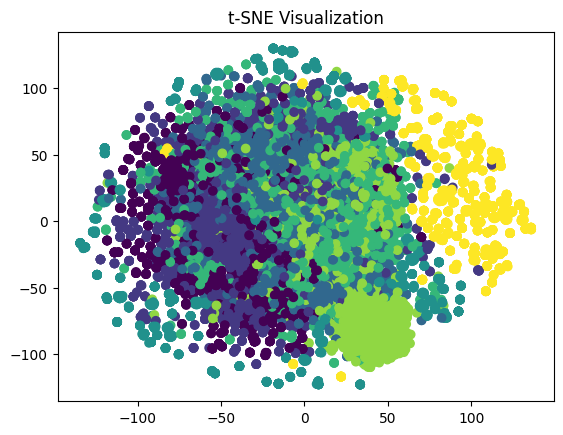

In [35]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
tsne_features = tsne.fit_transform(features)

plt.scatter(tsne_features[:,0], tsne_features[:,1], c=labels)
plt.title("t-SNE Visualization")
plt.show()

In [36]:
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

In [37]:
class ResNet50_Model(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        in_features = self.model.fc.in_features
        
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)


model_resnet = ResNet50_Model().to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


In [38]:
criterion_resnet = LabelSmoothingLoss()

optimizer_resnet = torch.optim.AdamW(
    model_resnet.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler_resnet = ReduceLROnPlateau(
    optimizer_resnet,
    mode='max',
    factor=0.5,
    patience=3
)

In [39]:
def train_resnet():
    
    model_resnet.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader):
        
        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet.zero_grad()

        outputs = model_resnet(images)
        loss = criterion_resnet(outputs, labels)

        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    
    return running_loss / len(train_loader), acc

In [40]:
def evaluate_resnet():
    
    model_resnet.eval()
    
    correct = 0
    total = 0
    
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        
        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_resnet(images)

            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total

    return acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [41]:
epochs = 30

best_acc_resnet = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_resnet()

    val_acc, labels, preds, probs = evaluate_resnet()

    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)

    scheduler_resnet.step(val_acc)

    if val_acc > best_acc_resnet:
        
        best_acc_resnet = val_acc
        
        torch.save(model_resnet.state_dict(), "resnet50_best.pth")
        
        print("Best model saved")
        


Epoch 1/30


100%|██████████| 74/74 [00:26<00:00,  2.80it/s]


Train Loss: 1.0449212023190089
Train Acc: 73.25290295088953
Val Acc: 87.08852668584213
Best model saved

Epoch 2/30


100%|██████████| 74/74 [00:27<00:00,  2.72it/s]


Train Loss: 0.8259751004021184
Train Acc: 84.48918717375093
Val Acc: 91.33908596995845
Best model saved

Epoch 3/30


...

Train Loss: 0.5339944674855187
Train Acc: 98.93736017897092
Val Acc: 98.83881964418877
Best model saved

Epoch 29/30


100%|██████████| 74/74 [00:26<00:00,  2.75it/s]


Train Loss: 0.5345842367937775
Train Acc: 98.92937040588048
Val Acc: 98.77490145946521

Epoch 30/30


100%|██████████| 74/74 [00:27<00:00,  2.70it/s]

Train Loss: 0.5339679551773331
Train Acc: 98.90806434430596
Val Acc: 98.29551507403856


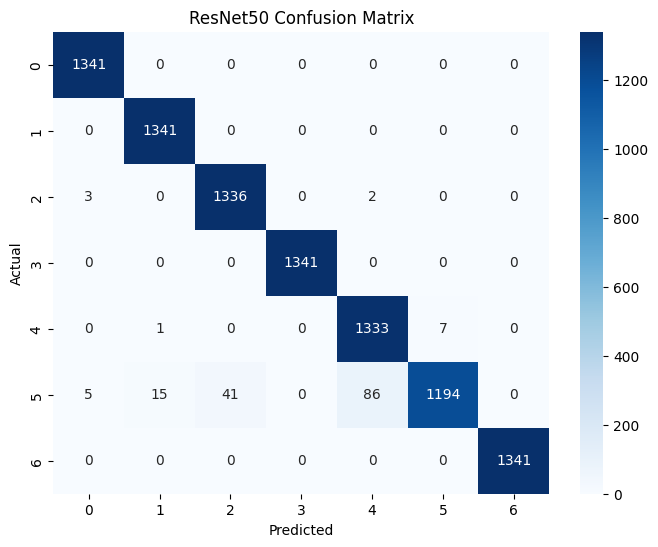

In [46]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("ResNet50 Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()





In [47]:
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1341
           1       0.99      1.00      0.99      1341
           2       0.97      1.00      0.98      1341
           3       1.00      1.00      1.00      1341
           4       0.94      0.99      0.97      1341
           5       0.99      0.89      0.94      1341
           6       1.00      1.00      1.00      1341

    accuracy                           0.98      9387
   macro avg       0.98      0.98      0.98      9387
weighted avg       0.98      0.98      0.98      9387



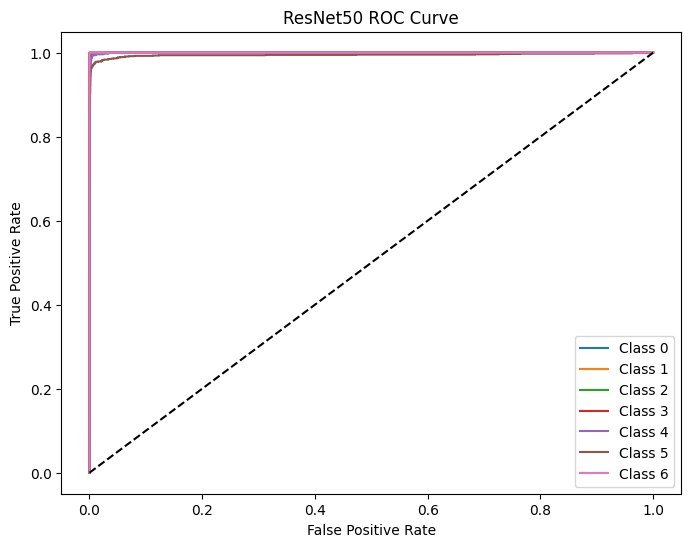

In [48]:
labels_bin = label_binarize(labels, classes=[0,1,2,3,4,5,6])

fpr = {}
tpr = {}

for i in range(7):

    fpr[i], tpr[i], _ = roc_curve(labels_bin[:,i], probs[:,i])

plt.figure(figsize=(8,6))

for i in range(7):

    plt.plot(fpr[i], tpr[i], label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.title("ResNet50 ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()


Epoch 1/30


100%|██████████| 74/74 [00:27<00:00,  2.73it/s]


Train Loss: 2.3670444865616
Train Acc: 47.36071162245659
Val Acc: 68.7333546393949
Best EfficientNet saved

Epoch 2/30


100%|██████████| 74/74 [00:26<00:00,  2.75it/s]


Train Loss: 1.178697096855462
Train Acc: 67.61478640673272
Val Acc: 81.15478853733887
Best EfficientNet saved

Epoch 3/30


...

Train Loss: 0.5384343633440887
Train Acc: 99.01459465217854
Val Acc: 98.806860551827
Best EfficientNet saved

Epoch 29/30


100%|██████████| 74/74 [00:26<00:00,  2.81it/s]


Train Loss: 0.5257484404002728
Train Acc: 99.46734846063706
Val Acc: 98.8601257057633
Best EfficientNet saved

Epoch 30/30


100%|██████████| 74/74 [00:25<00:00,  2.86it/s]


Train Loss: 0.5223301697750481
Train Acc: 99.50463406839246
Val Acc: 98.8601257057633


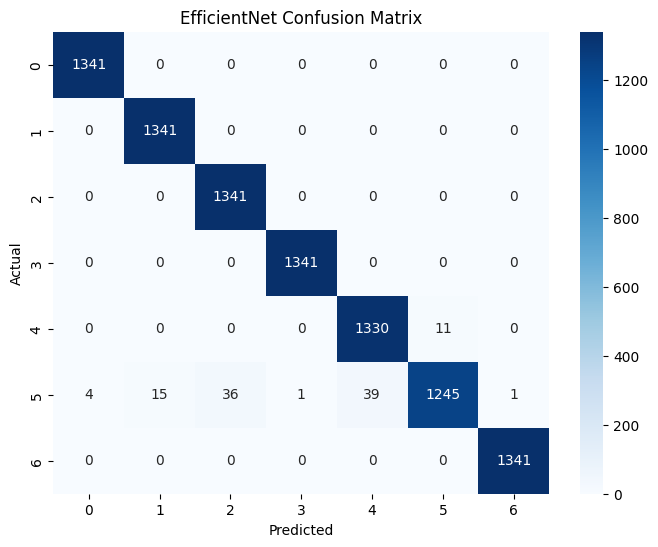

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       0.99      1.00      0.99      1341
           2       0.97      1.00      0.99      1341
           3       1.00      1.00      1.00      1341
           4       0.97      0.99      0.98      1341
           5       0.99      0.93      0.96      1341
           6       1.00      1.00      1.00      1341

    accuracy                           0.99      9387
   macro avg       0.99      0.99      0.99      9387
weighted avg       0.99      0.99      0.99      9387



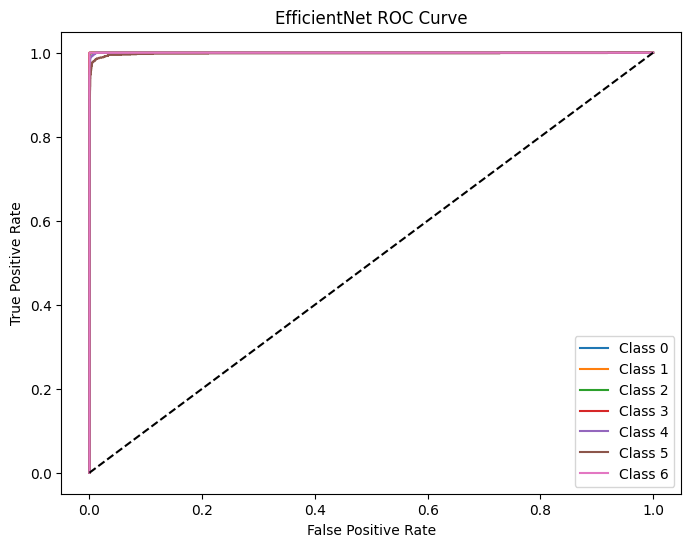

In [49]:
import timm

class EfficientNet_Model(nn.Module):
    
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.model = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)


model_effnet = EfficientNet_Model().to(device)

criterion_effnet = LabelSmoothingLoss()

optimizer_effnet = torch.optim.AdamW(
    model_effnet.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler_effnet = ReduceLROnPlateau(
    optimizer_effnet,
    mode='max',
    factor=0.5,
    patience=3
)

def train_effnet():

    model_effnet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer_effnet.zero_grad()

        outputs = model_effnet(images)

        loss = criterion_effnet(outputs, labels)

        loss.backward()

        optimizer_effnet.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    acc = 100 * correct / total

    return running_loss/len(train_loader), acc


def evaluate_effnet():

    model_effnet.eval()

    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_effnet(images)

            probs = torch.softmax(outputs,dim=1)

            _, preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total

    return acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

epochs = 30

best_acc_effnet = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_effnet()

    val_acc, labels_eff, preds_eff, probs_eff = evaluate_effnet()

    print("Train Loss:",train_loss)
    print("Train Acc:",train_acc)
    print("Val Acc:",val_acc)

    scheduler_effnet.step(val_acc)

    if val_acc > best_acc_effnet:

        best_acc_effnet = val_acc

        torch.save(model_effnet.state_dict(),"efficientnet_best.pth")

        print("Best EfficientNet saved")

cm = confusion_matrix(labels_eff, preds_eff)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("EfficientNet Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(classification_report(labels_eff,preds_eff))

labels_bin = label_binarize(labels_eff, classes=[0,1,2,3,4,5,6])

fpr = {}
tpr = {}

for i in range(7):

    fpr[i], tpr[i], _ = roc_curve(labels_bin[:,i], probs_eff[:,i])

plt.figure(figsize=(8,6))

for i in range(7):

    plt.plot(fpr[i],tpr[i],label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.title("EfficientNet ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()



Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 158MB/s]



Epoch 1/30


100%|██████████| 74/74 [00:26<00:00,  2.80it/s]


Train Loss: 1.1470751294067927
Train Acc: 67.6467454990945
Val Acc: 81.58090976882923
Best MobileNet saved

Epoch 2/30


...

Train Loss: 0.5495681722147935
Train Acc: 98.5352082667519
Val Acc: 98.81751358261425
Best MobileNet saved

Epoch 29/30


100%|██████████| 74/74 [00:26<00:00,  2.82it/s]


Train Loss: 0.5450880002407801
Train Acc: 98.65771812080537
Val Acc: 98.31682113561308

Epoch 30/30


100%|██████████| 74/74 [00:26<00:00,  2.82it/s]


Train Loss: 0.5438719341138594
Train Acc: 98.87344199424736
Val Acc: 98.72163630552892


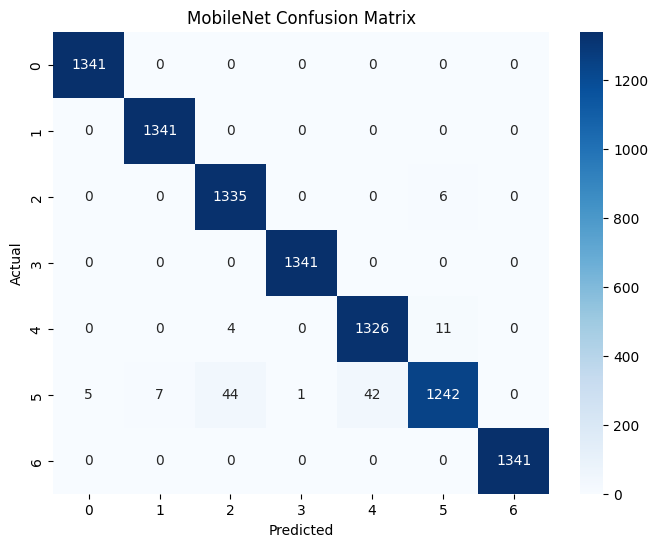

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       0.99      1.00      1.00      1341
           2       0.97      1.00      0.98      1341
           3       1.00      1.00      1.00      1341
           4       0.97      0.99      0.98      1341
           5       0.99      0.93      0.96      1341
           6       1.00      1.00      1.00      1341

    accuracy                           0.99      9387
   macro avg       0.99      0.99      0.99      9387
weighted avg       0.99      0.99      0.99      9387



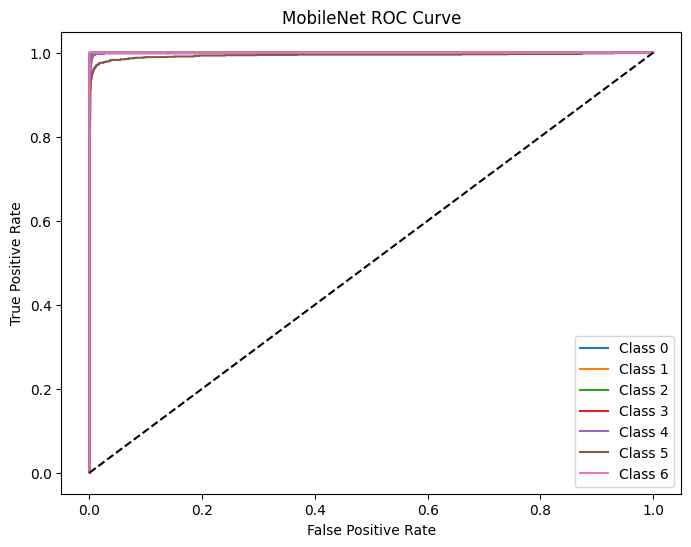

In [50]:
import torchvision.models as models

class MobileNet_Model(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()

        self.model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


model_mobilenet = MobileNet_Model().to(device)

criterion_mobilenet = LabelSmoothingLoss()

optimizer_mobilenet = torch.optim.AdamW(
    model_mobilenet.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler_mobilenet = ReduceLROnPlateau(
    optimizer_mobilenet,
    mode='max',
    factor=0.5,
    patience=3
)

def train_mobilenet():

    model_mobilenet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer_mobilenet.zero_grad()

        outputs = model_mobilenet(images)

        loss = criterion_mobilenet(outputs, labels)

        loss.backward()

        optimizer_mobilenet.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    acc = 100 * correct / total

    return running_loss/len(train_loader), acc

def evaluate_mobilenet():

    model_mobilenet.eval()

    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_mobilenet(images)

            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total

    return acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

epochs = 30

best_acc_mobile = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_mobilenet()

    val_acc, labels_mobile, preds_mobile, probs_mobile = evaluate_mobilenet()

    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)

    scheduler_mobilenet.step(val_acc)

    if val_acc > best_acc_mobile:

        best_acc_mobile = val_acc

        torch.save(model_mobilenet.state_dict(), "mobilenet_best.pth")

        print("Best MobileNet saved")


cm = confusion_matrix(labels_mobile, preds_mobile)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("MobileNet Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(labels_mobile, preds_mobile))

labels_bin = label_binarize(labels_mobile, classes=[0,1,2,3,4,5,6])

fpr = {}
tpr = {}

for i in range(7):

    fpr[i], tpr[i], _ = roc_curve(labels_bin[:,i], probs_mobile[:,i])

plt.figure(figsize=(8,6))

for i in range(7):
    plt.plot(fpr[i], tpr[i], label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.title("MobileNet ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()



Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 211MB/s]



Epoch 1/30


100%|██████████| 74/74 [00:26<00:00,  2.83it/s]


Train Loss: 1.1027039686838787
Train Acc: 70.27271758815382
Val Acc: 86.91807819324598
Best DenseNet saved

Epoch 2/30


...

Train Loss: 0.5282199575382025
Train Acc: 99.32885906040268
Val Acc: 98.61510599765633

Epoch 29/30


100%|██████████| 74/74 [00:27<00:00,  2.74it/s]


Train Loss: 0.5225603511544312
Train Acc: 99.57654202620645
Val Acc: 98.97730904442314

Epoch 30/30


100%|██████████| 74/74 [00:26<00:00,  2.74it/s]


Train Loss: 0.5199201682797906
Train Acc: 99.67774581868541
Val Acc: 99.05188025993395
Best DenseNet saved


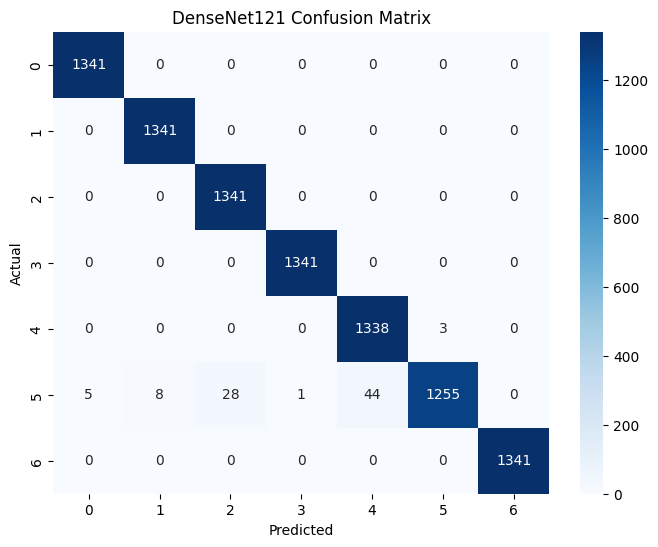

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       0.99      1.00      1.00      1341
           2       0.98      1.00      0.99      1341
           3       1.00      1.00      1.00      1341
           4       0.97      1.00      0.98      1341
           5       1.00      0.94      0.97      1341
           6       1.00      1.00      1.00      1341

    accuracy                           0.99      9387
   macro avg       0.99      0.99      0.99      9387
weighted avg       0.99      0.99      0.99      9387



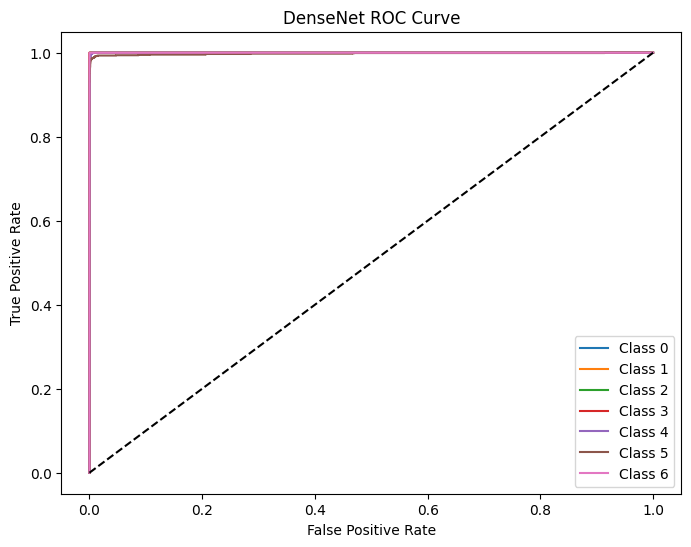

In [51]:
import torchvision.models as models

class DenseNet_Model(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()

        self.model = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )

        in_features = self.model.classifier.in_features

        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)


model_densenet = DenseNet_Model().to(device)

criterion_dense = LabelSmoothingLoss()

optimizer_dense = torch.optim.AdamW(
    model_densenet.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler_dense = ReduceLROnPlateau(
    optimizer_dense,
    mode="max",
    factor=0.5,
    patience=3
)

def train_densenet():

    model_densenet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer_dense.zero_grad()

        outputs = model_densenet(images)

        loss = criterion_dense(outputs, labels)

        loss.backward()

        optimizer_dense.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    acc = 100 * correct / total

    return running_loss/len(train_loader), acc


def evaluate_densenet():

    model_densenet.eval()

    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_densenet(images)

            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total

    return acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

epochs = 30

best_acc_dense = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_densenet()

    val_acc, labels_dense, preds_dense, probs_dense = evaluate_densenet()

    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)

    scheduler_dense.step(val_acc)

    if val_acc > best_acc_dense:

        best_acc_dense = val_acc

        torch.save(model_densenet.state_dict(), "densenet_best.pth")

        print("Best DenseNet saved")


cm = confusion_matrix(labels_dense, preds_dense)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("DenseNet121 Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(labels_dense, preds_dense))

labels_bin = label_binarize(labels_dense, classes=[0,1,2,3,4,5,6])

fpr = {}
tpr = {}

for i in range(7):

    fpr[i], tpr[i], _ = roc_curve(labels_bin[:,i], probs_dense[:,i])

plt.figure(figsize=(8,6))

for i in range(7):
    plt.plot(fpr[i], tpr[i], label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.title("DenseNet ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [53]:
custom_model = DCNN().to(device)
custom_model.load_state_dict(torch.load("best_model.pth"))
custom_model.eval()

resnet_model = ResNet50_Model().to(device)
resnet_model.load_state_dict(torch.load("resnet50_best.pth"))
resnet_model.eval()

effnet_model = EfficientNet_Model().to(device)
effnet_model.load_state_dict(torch.load("efficientnet_best.pth"))
effnet_model.eval()

mobilenet_model = MobileNet_Model().to(device)
mobilenet_model.load_state_dict(torch.load("mobilenet_best.pth"))
mobilenet_model.eval()

densenet_model = DenseNet_Model().to(device)
densenet_model.load_state_dict(torch.load("densenet_best.pth"))
densenet_model.eval()

models_list = [
    custom_model,
    resnet_model,
    effnet_model,
    mobilenet_model,
    densenet_model
]

In [54]:
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    
    for images, labels in tqdm(val_loader):

        images = images.to(device)

        probs = []

        for m in models_list:

            outputs = m(images)

            p = torch.softmax(outputs, dim=1)

            probs.append(p)

        avg_probs = torch.stack(probs).mean(dim=0)

        preds = torch.argmax(avg_probs, dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(avg_probs.cpu().numpy())

labels_ens = np.array(all_labels)
preds_ens = np.array(all_preds)
probs_ens = np.array(all_probs)

100%|██████████| 74/74 [00:27<00:00,  2.73it/s]


In [55]:
from sklearn.metrics import accuracy_score

ensemble_acc = accuracy_score(labels_ens, preds_ens)

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 0.992223287525301


In [56]:
from sklearn.metrics import f1_score

f1 = f1_score(labels_ens, preds_ens, average="weighted")

print("Ensemble F1 Score:", f1)

Ensemble F1 Score: 0.9921584860264151


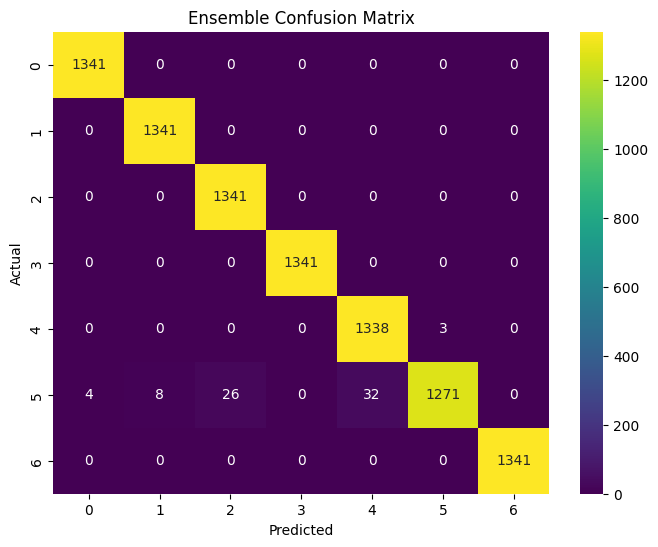

In [57]:
cm = confusion_matrix(labels_ens, preds_ens)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")

plt.title("Ensemble Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

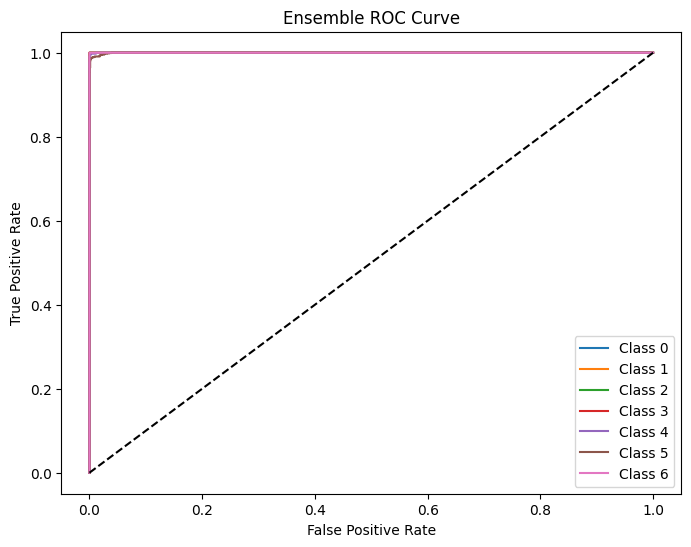

In [58]:
labels_bin = label_binarize(labels_ens, classes=[0,1,2,3,4,5,6])

plt.figure(figsize=(8,6))

for i in range(7):

    fpr, tpr, _ = roc_curve(labels_bin[:,i], probs_ens[:,i])

    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')

plt.title("Ensemble ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [60]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.4 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [80]:
!pip install --upgrade grad-cam

In [81]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import cv2


In [82]:
target_layer = model_resnet.model.layer4[-1]

In [84]:
target_layer = model_effnet.model.conv_head

In [85]:
images, labels = next(iter(val_loader))

image = images[0].unsqueeze(0).to(device)

label = labels[0]

In [89]:
# ✅ Step 5 - Fixed Version
target_layer = model_resnet.model.layer4[-1]
target_layer.requires_grad_(True)  # 👈 Add this line

cam = GradCAM(
    model=model_resnet,
    target_layers=[target_layer]   # 👈 also removed use_cuda
)

targets = [ClassifierOutputTarget(label)]

grayscale_cam = cam(
    input_tensor=image,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

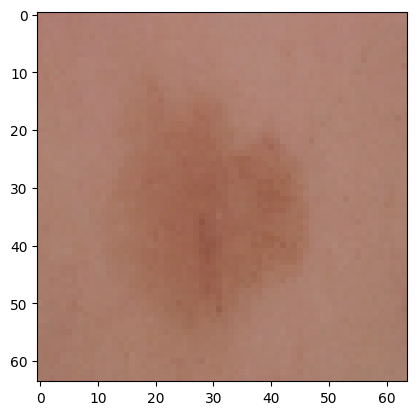

In [94]:
plt.imshow(img)  # Should show a recognizable skin lesion photo
plt.show()

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

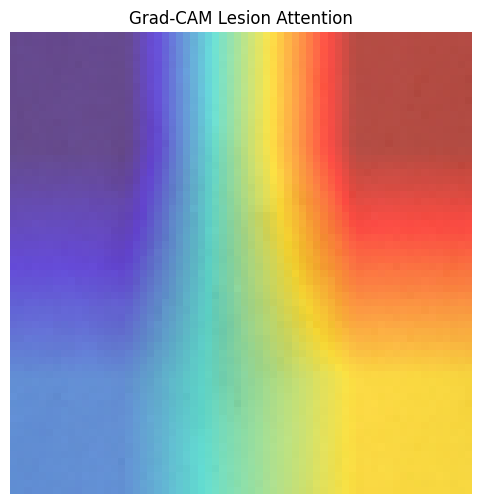

In [93]:
# ✅ Correct image preparation
img = images[0].cpu().numpy().transpose(1, 2, 0)  # CHW → HWC

# Undo ImageNet normalization (must match your val_loader transforms)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img  = std * img + mean
img  = np.clip(img, 0, 1).astype(np.float32)  # must be float32 in [0,1]

# Overlay heatmap
visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title("Grad-CAM Lesion Attention")
plt.axis("off")

In [96]:
# 🔍 Run this first to inspect grayscale_cam
print("Shape:", grayscale_cam.shape)
print("Min:", grayscale_cam.min())
print("Max:", grayscale_cam.max())
print("Dtype:", grayscale_cam.dtype)

Shape: (64, 64)
Min: 0.0
Max: 0.9999999
Dtype: float32


In [97]:
# ✅ Full corrected Grad-CAM block
model_resnet.eval()

target_layer = model_resnet.model.layer4[-1]
target_layer.requires_grad_(True)

cam = GradCAM(model=model_resnet, target_layers=[target_layer])

# Enable gradients for inference
with torch.enable_grad():
    grayscale_cam = cam(
        input_tensor=image,
        targets=[ClassifierOutputTarget(label)]
    )

grayscale_cam = grayscale_cam[0]

# 🔍 Verify before plotting
print("Shape:", grayscale_cam.shape)
print("Range:", grayscale_cam.min(), "→", grayscale_cam.max())

Shape: (64, 64)
Range: 0.0 → 0.9999999


img shape: (64, 64, 3)
cam shape: (64, 64)


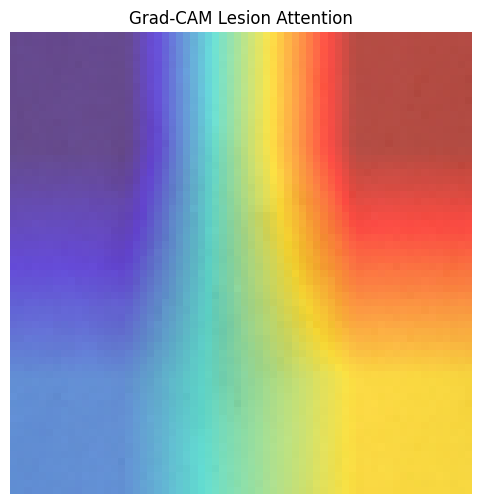

In [98]:
import cv2
import numpy as np

# ✅ Image prep
img = images[0].cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img  = std * img + mean
img  = np.clip(img, 0, 1).astype(np.float32)

# ✅ Resize CAM to exactly match image size
h, w = img.shape[:2]
grayscale_cam_resized = cv2.resize(grayscale_cam, (w, h))

# ✅ Verify sizes match before overlay
print("img shape:", img.shape)           # should be (64, 64, 3)
print("cam shape:", grayscale_cam_resized.shape)  # should be (64, 64)

# ✅ Overlay
visualization = show_cam_on_image(img, grayscale_cam_resized, use_rgb=True)

plt.figure(figsize=(6, 6))
plt.imshow(visualization)
plt.title("Grad-CAM Lesion Attention")
plt.axis("off")
plt.show()

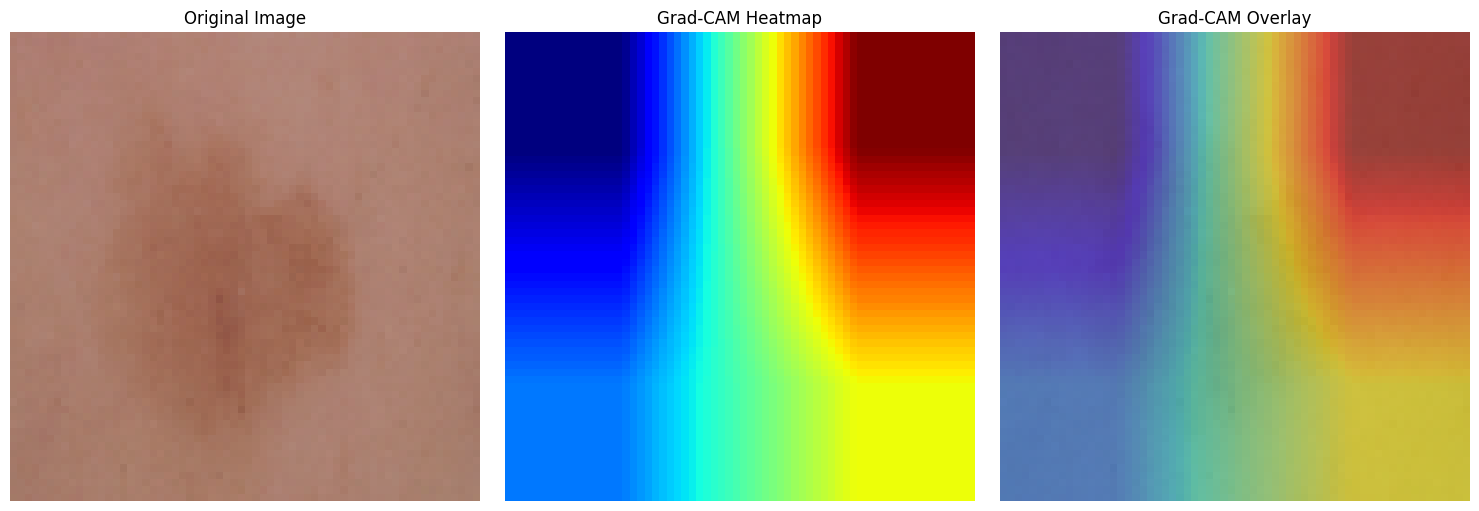

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Get the raw image correctly
img = images[0].cpu().numpy().transpose(1, 2, 0)  # (64, 64, 3)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img  = (img * std) + mean          # undo normalization
img  = np.clip(img, 0, 1)          # clamp
img  = img.astype(np.float32)

# Step 2: Convert grayscale_cam to RGBA heatmap
heatmap = cm.jet(grayscale_cam)[:, :, :3]  # (64, 64, 3), RGB only
heatmap = heatmap.astype(np.float32)

# Step 3: Blend manually
alpha = 0.5
visualization = alpha * heatmap + (1 - alpha) * img
visualization = np.clip(visualization, 0, 1)

# Step 4: Plot both side by side for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(visualization)
axes[2].set_title("Grad-CAM Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [100]:
# Check if grayscale_cam is literally just a gradient
print(grayscale_cam[:, 0])   # first column values
print(grayscale_cam[:, 32])  # middle column values  
print(grayscale_cam[:, 63])  # last column values
print(grayscale_cam[0, :])   # first row - if smoothly increasing, it's a gradient artifact

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.00383646 0.01150936
 0.01918227 0.02685519 0.0345281  0.042201   0.04987392 0.05754683
 0.06521974 0.07289265 0.08056556 0.08823847 0.09591138 0.10358428
 0.1112572  0.1189301  0.12660302 0.13427593 0.14194883 0.14962174
 0.15729466 0.16496757 0.17264047 0.1803134  0.1879863  0.1956592
 0.20333211 0.21100503 0.21867792 0.22635084 0.23402376 0.24169667
 0.24553312 0.24553312 0.24553312 0.24553312 0.24553312 0.24553312
 0.24553312 0.24553312 0.24553312 0.24553312 0.24553312 0.24553312
 0.24553312 0.24553312 0.24553312 0.24553312]
[0.51562494 0.51562494 0.51562494 0.51562494 0.51562494 0.51562494
 0.51562494 0.51562494 0.51562494 0.51562494 0.51562494 0.51562494
 0.51562494 0.51562494 0.51562494 0.51562494 0.5145879  0.51251364
 0.5104395  0.5083654  0.5062912  0.504217   0.50214285 0.5000687
 0.49799457 0.4959204  0.49384624 

In [102]:
# FIX 1: Make sure model is NOT inside torch.no_grad() anywhere above
# Check your training/eval setup - this is the #1 cause

# FIX 2: Try a different target - use None to let Grad-CAM pick the top class
with torch.enable_grad():
    grayscale_cam = cam(
        input_tensor=image,
        targets=None      # 👈 Let it auto-select highest scoring class
    )

grayscale_cam = grayscale_cam[0]
print("Range:", grayscale_cam.min(), grayscale_cam.max())
print("Std:", grayscale_cam.std())   # if near 0, gradients are still flat

Range: 0.0 0.9999999
Std: 0.30294278


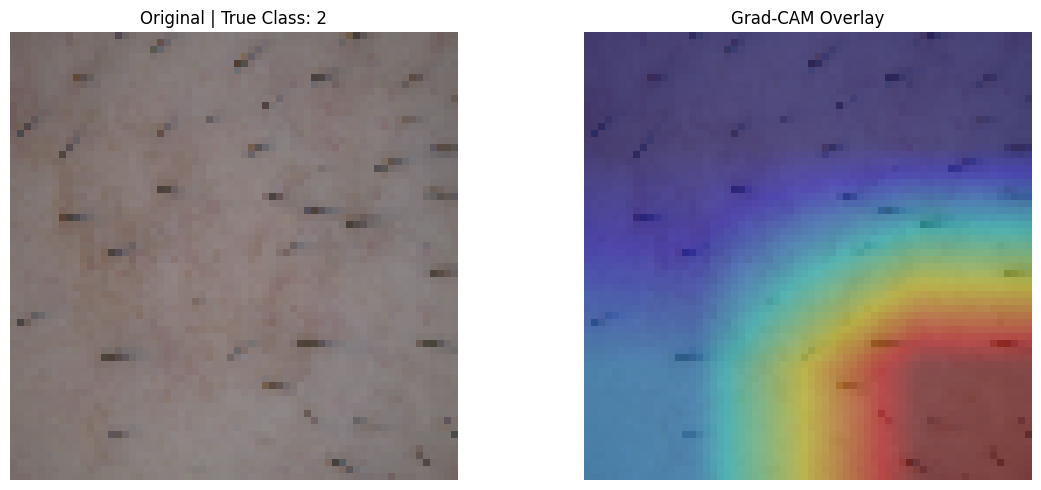

In [103]:
# ✅ Complete working Grad-CAM - copy and run this entire block

# Step 1: Load best weights
model_resnet.load_state_dict(torch.load("resnet50_best.pth", map_location=device))
model_resnet.eval()

# Step 2: Get sample
images, labels = next(iter(val_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0].item()  # 👈 .item() to convert tensor to int

# Step 3: Grad-CAM
target_layer = model_resnet.model.layer4[-1]
target_layer.requires_grad_(True)

cam = GradCAM(model=model_resnet, target_layers=[target_layer])

with torch.enable_grad():
    grayscale_cam = cam(input_tensor=image, targets=None)

grayscale_cam = grayscale_cam[0]

# Step 4: Prepare image
img = images[0].cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img  = (img * std) + mean
img  = np.clip(img, 0, 1).astype(np.float32)

# Step 5: Overlay using OpenCV (bypasses show_cam_on_image entirely)
import cv2
heatmap = cv2.applyColorMap(np.uint8(255 * grayscale_cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0  # BGR→RGB, normalize
heatmap = heatmap.astype(np.float32)

overlay = 0.4 * heatmap + 0.6 * img
overlay = np.clip(overlay, 0, 1)

# Step 6: Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original | True Class: {label}")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("Grad-CAM Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

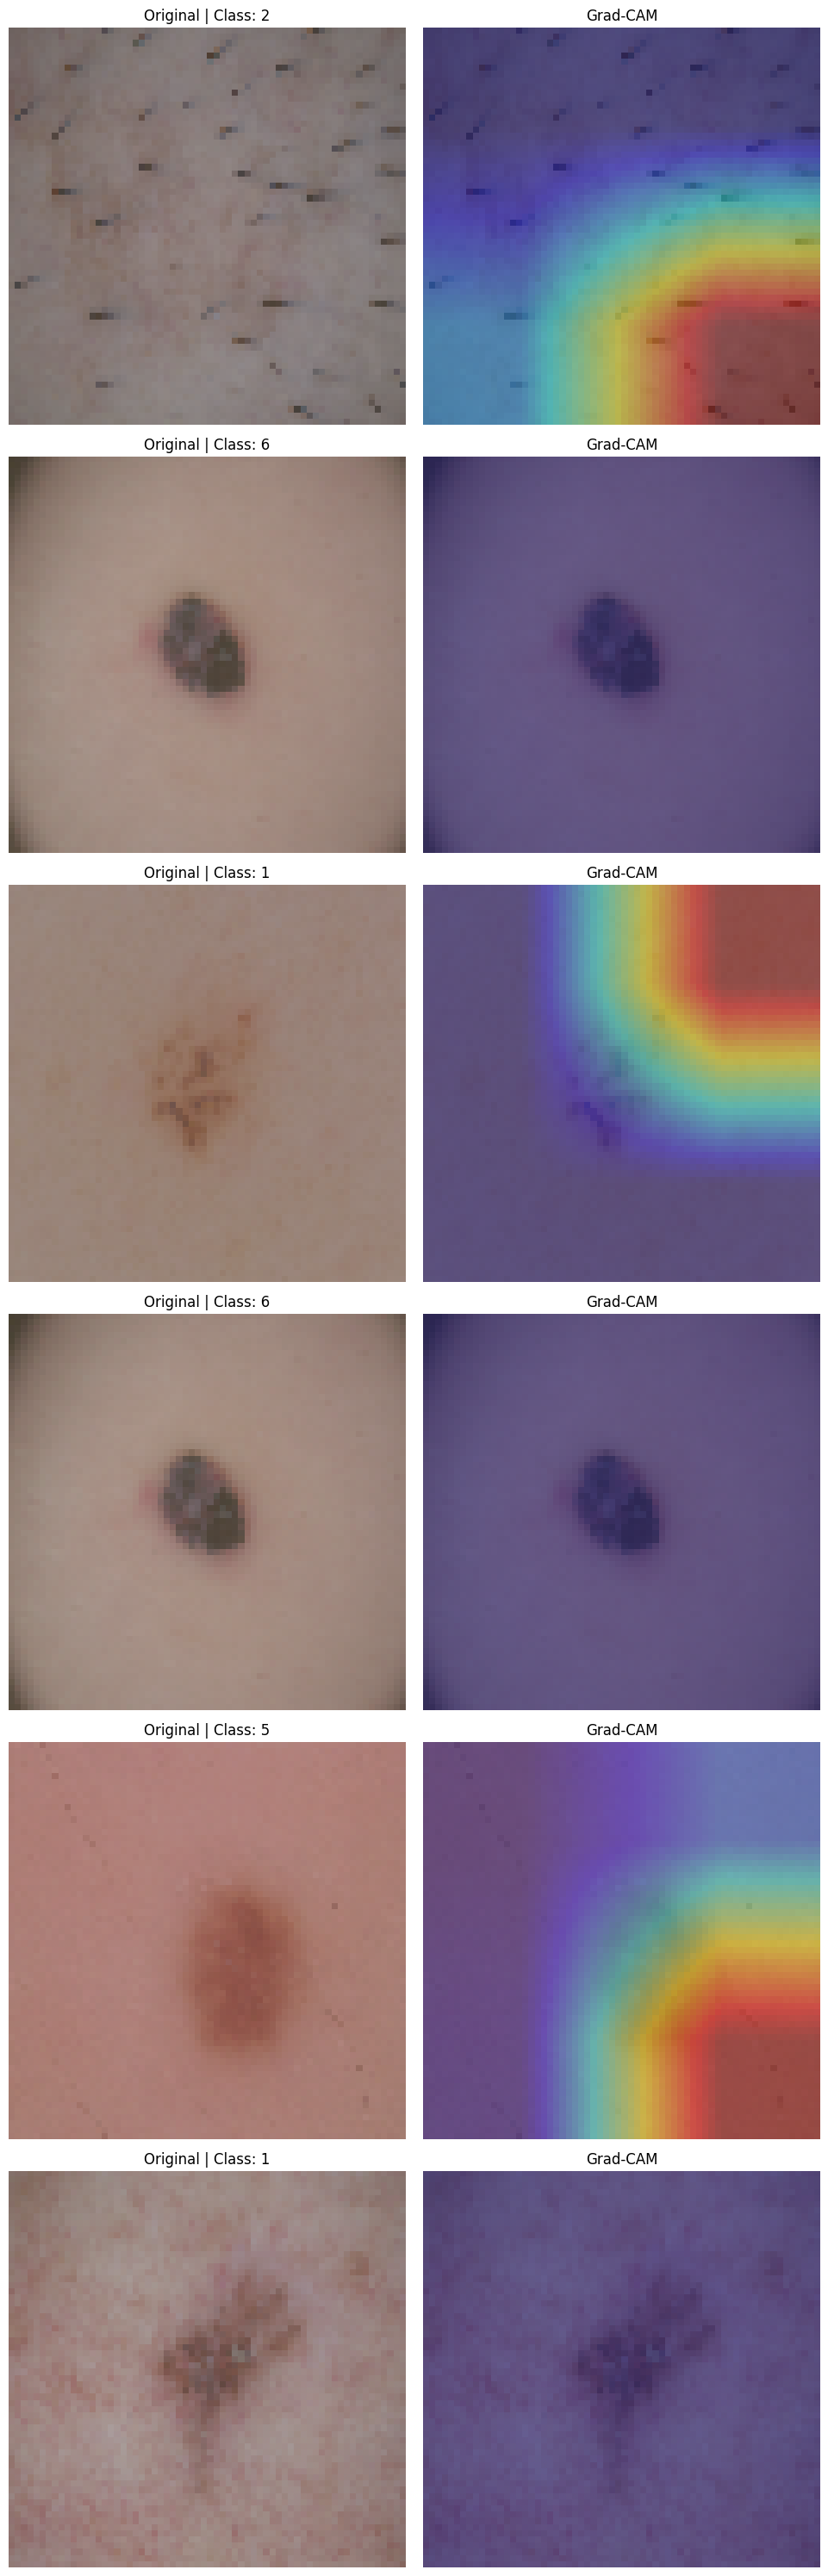

In [104]:
# ✅ Visualize Grad-CAM on 6 samples at once
fig, axes = plt.subplots(6, 2, figsize=(10, 30))

cam = GradCAM(model=model_resnet, target_layers=[model_resnet.model.layer4[-1]])

for idx in range(6):
    image_single = images[idx].unsqueeze(0).to(device)
    
    with torch.enable_grad():
        gc = cam(input_tensor=image_single, targets=None)[0]
    
    # Prepare image
    img_np = images[idx].cpu().numpy().transpose(1, 2, 0)
    img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1).astype(np.float32)
    
    # Overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * gc), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.4 * heatmap + 0.6 * img_np, 0, 1)
    
    axes[idx, 0].imshow(img_np)
    axes[idx, 0].set_title(f"Original | Class: {labels[idx].item()}")
    axes[idx, 0].axis("off")
    
    axes[idx, 1].imshow(overlay)
    axes[idx, 1].set_title("Grad-CAM")
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

In [105]:
features_list = []
labels_list = []

model_effnet.eval()

with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(device)

        feats = model_effnet.model.forward_features(images)
        feats = torch.mean(feats, dim=[2,3])  # global pooling

        features_list.append(feats.cpu().numpy())
        labels_list.append(labels.numpy())

features = np.concatenate(features_list)
labels_feat = np.concatenate(labels_list)

print("Feature shape:", features.shape)

100%|██████████| 74/74 [00:26<00:00,  2.75it/s]

Feature shape: (9387, 1280)


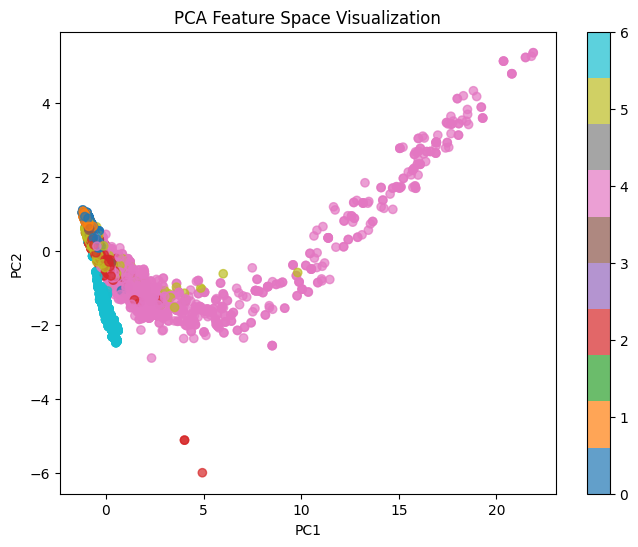

In [106]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

features_pca = pca.fit_transform(features)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    features_pca[:,0],
    features_pca[:,1],
    c=labels_feat,
    cmap="tab10",
    alpha=0.7
)

plt.title("PCA Feature Space Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


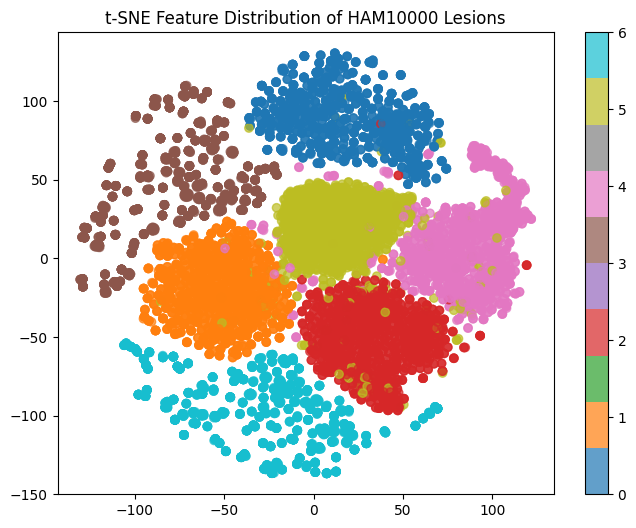

In [107]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

features_tsne = tsne.fit_transform(features)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    features_tsne[:,0],
    features_tsne[:,1],
    c=labels_feat,
    cmap="tab10",
    alpha=0.7
)

plt.title("t-SNE Feature Distribution of HAM10000 Lesions")

plt.colorbar(scatter)

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


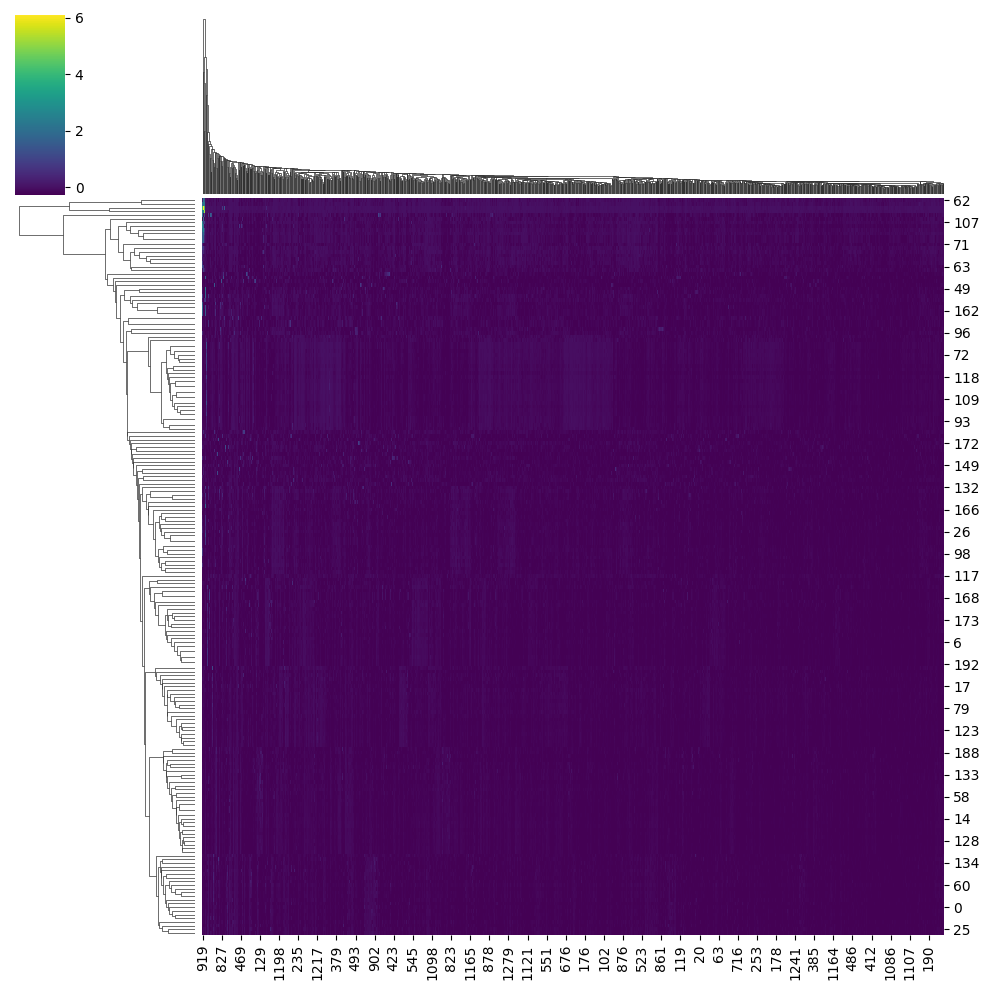

In [108]:
import seaborn as sns

sample_idx = np.random.choice(len(features), 200)

sample_features = features[sample_idx]

sns.clustermap(
    sample_features,
    cmap="viridis",
    figsize=(10,10)
)

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


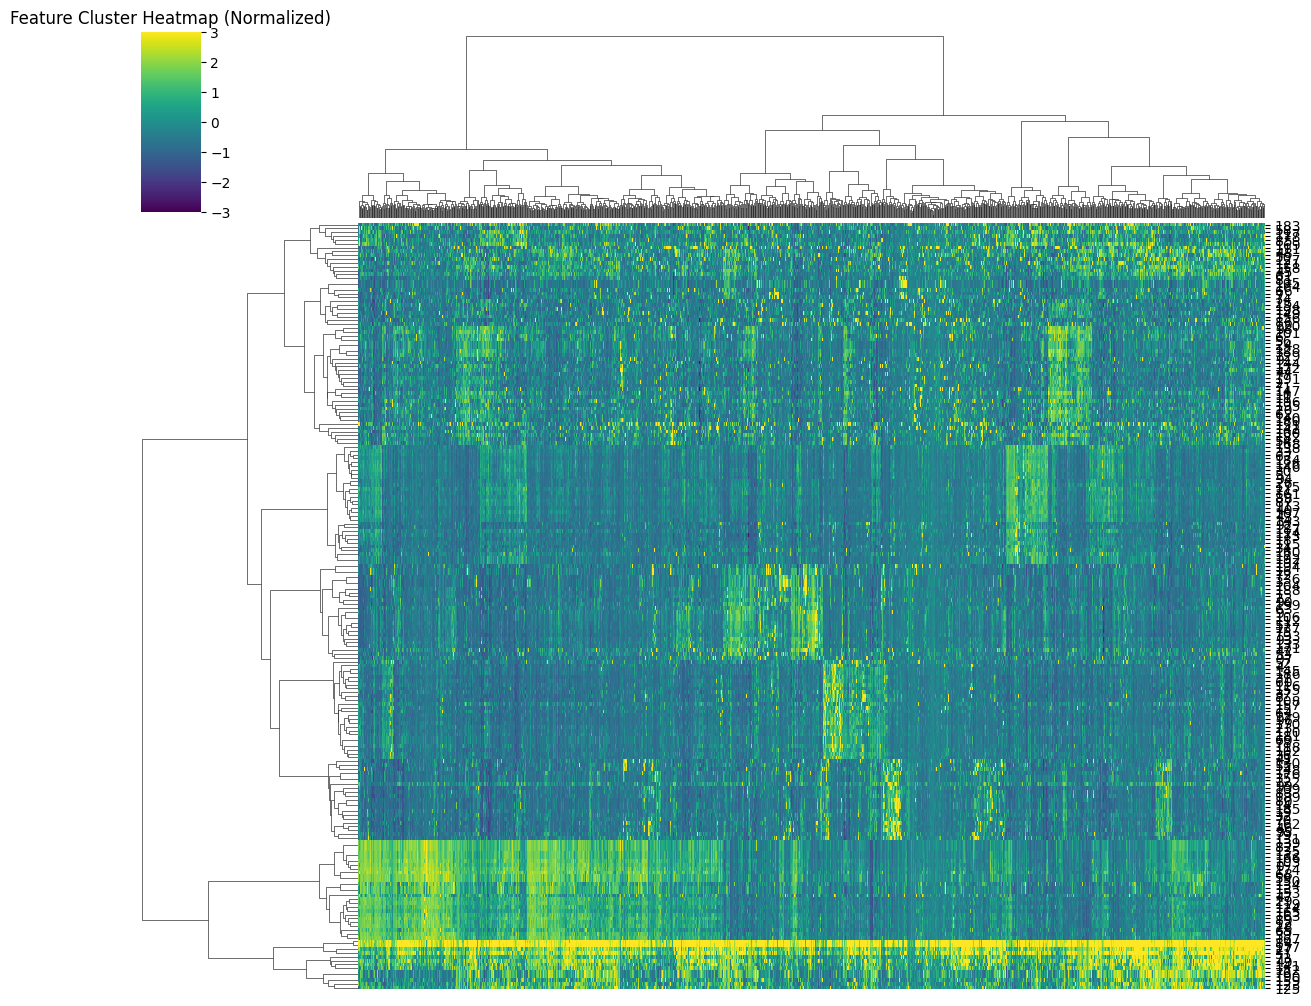

In [109]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

# Step 1: Sample
sample_idx = np.random.choice(len(features), 200)
sample_features = features[sample_idx]

# Step 2: Normalize (z-score per feature column)
scaler = StandardScaler()
sample_features_scaled = scaler.fit_transform(sample_features)

# Step 3: Clip extreme outliers (anything beyond 3 std devs)
sample_features_clipped = np.clip(sample_features_scaled, -3, 3)

# Step 4: Plot
sns.clustermap(
    sample_features_clipped,
    cmap="viridis",
    figsize=(12, 10),
    xticklabels=False,   # too many features to label
    yticklabels=True,
    method='ward',        # better clustering than default
    metric='euclidean'
)
plt.title("Feature Cluster Heatmap (Normalized)")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


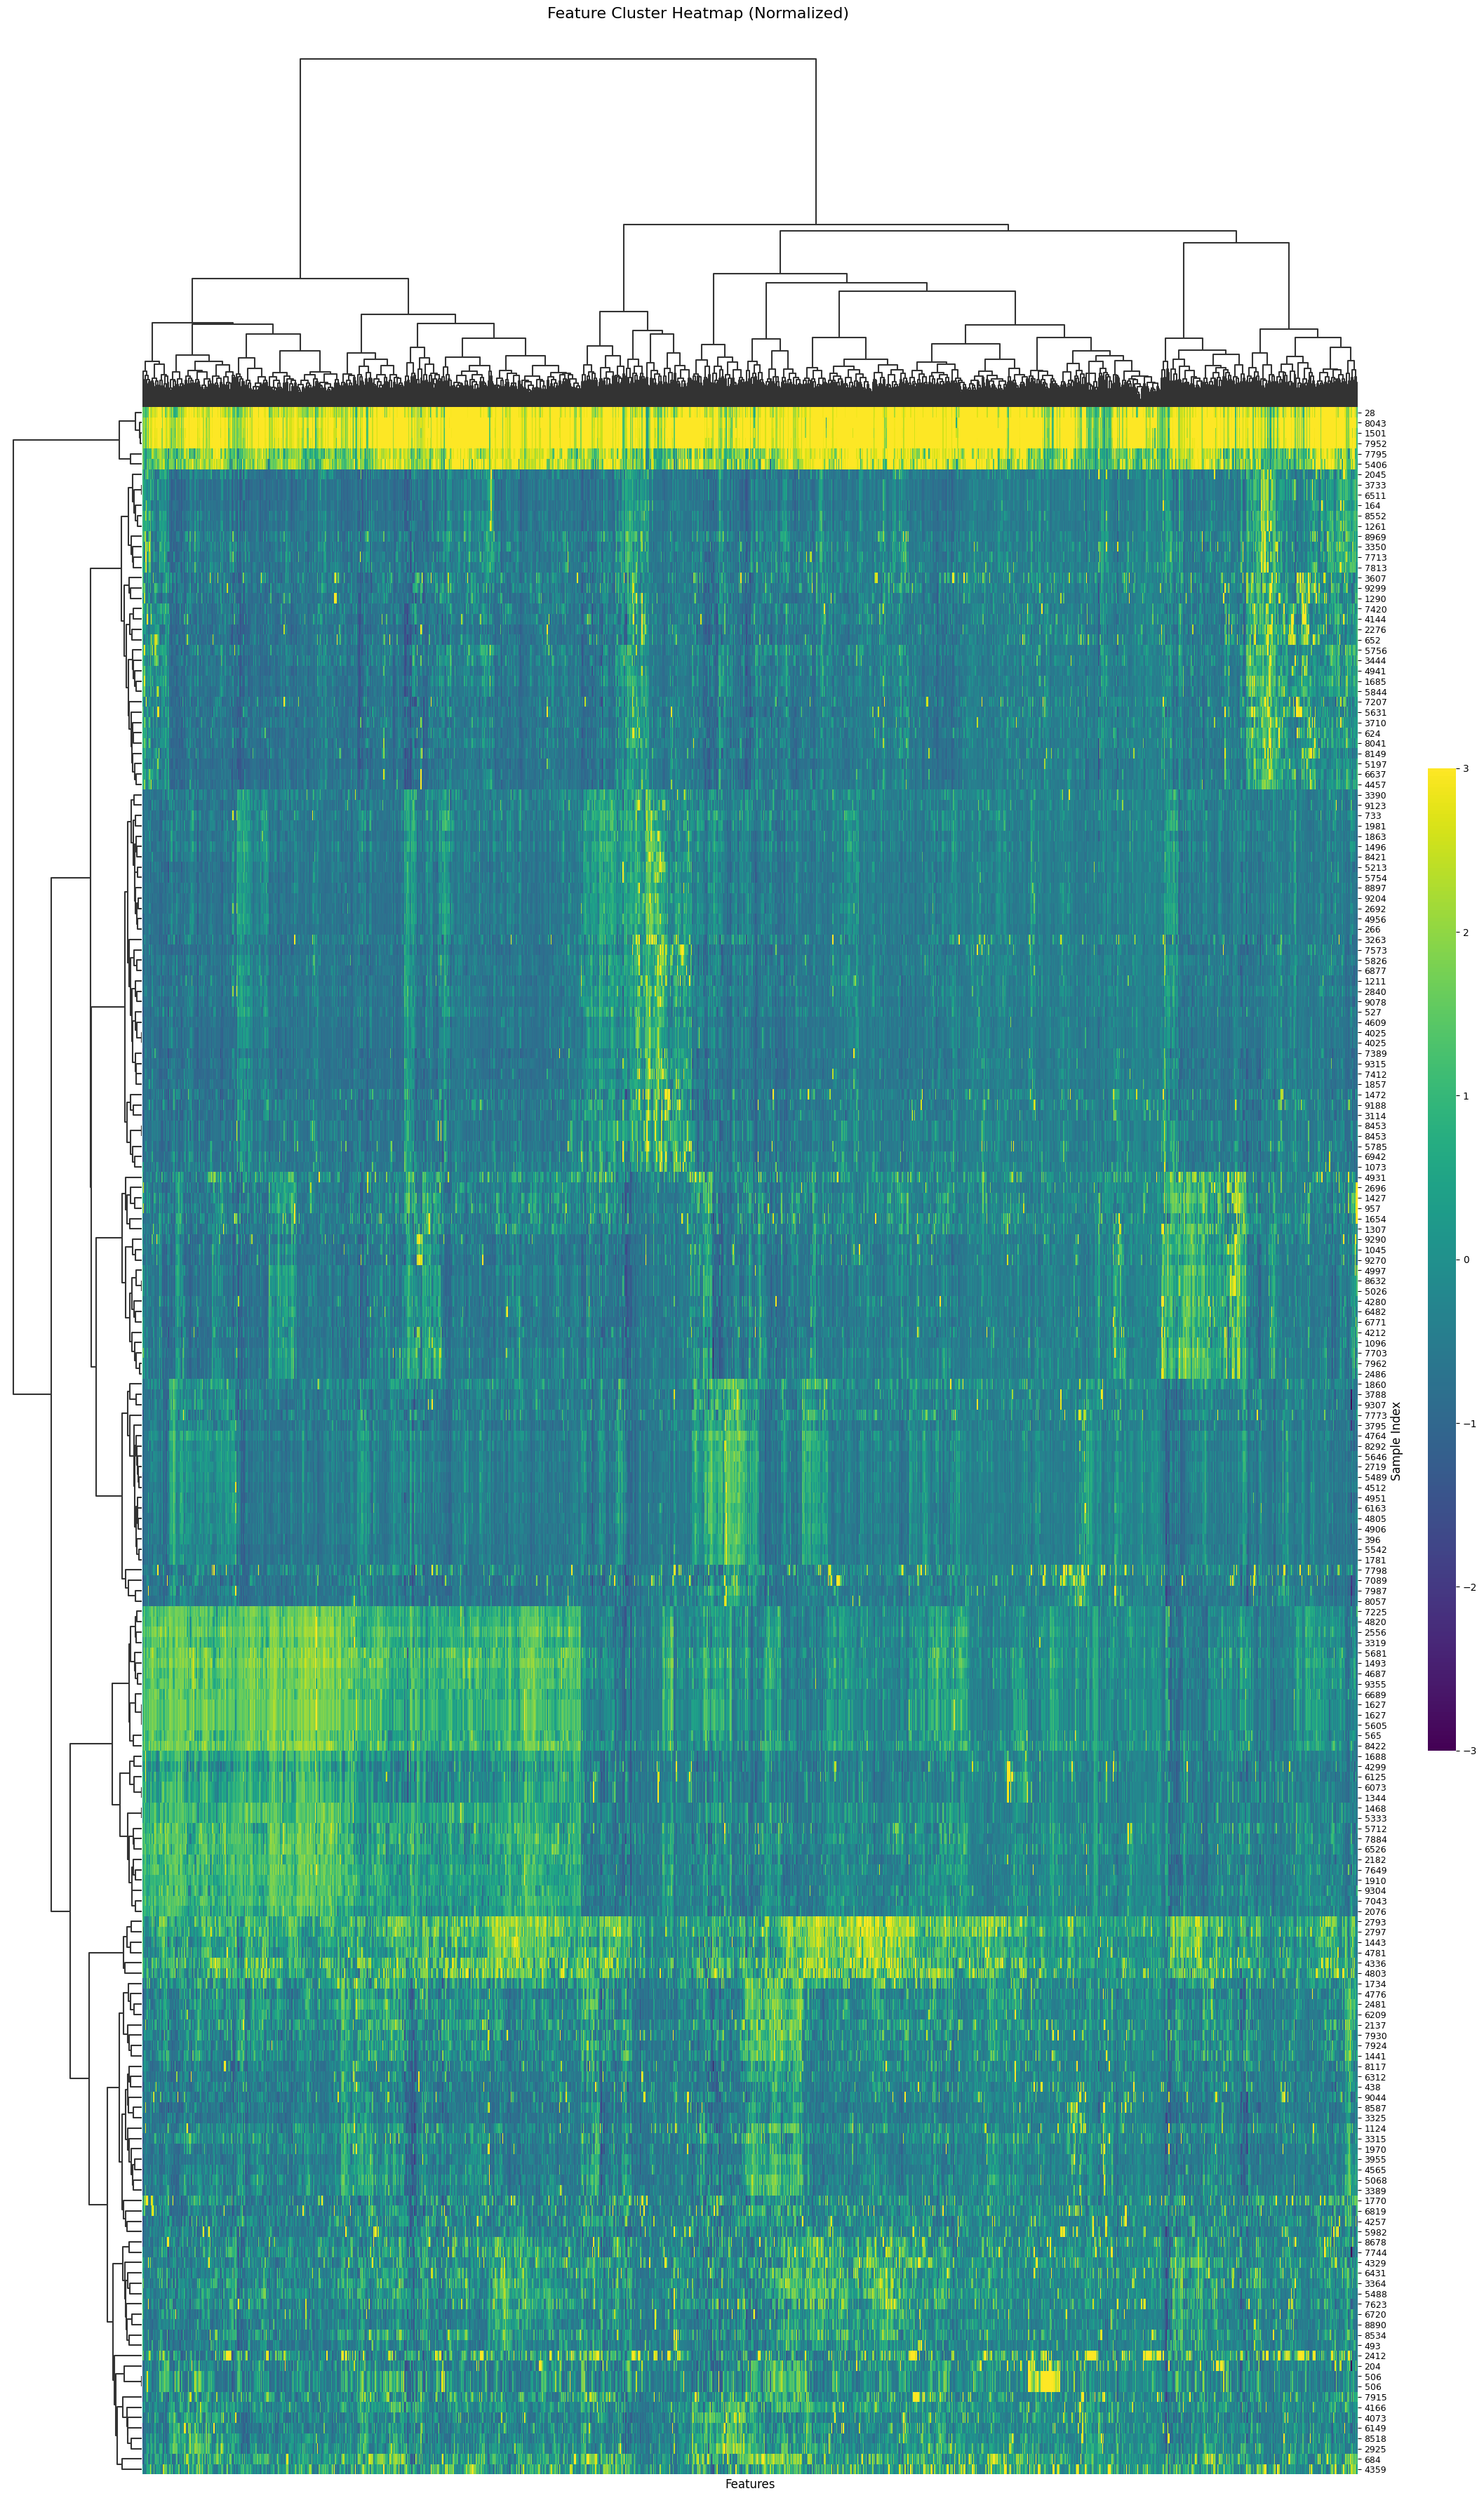

In [110]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

# Steps 1-3 same
sample_idx = np.random.choice(len(features), 200)
sample_features = features[sample_idx]
scaler = StandardScaler()
sample_features_scaled = scaler.fit_transform(sample_features)
sample_features_clipped = np.clip(sample_features_scaled, -3, 3)

# Get sample labels for y-axis
sample_labels = [str(i) for i in sample_idx]  # or use actual class labels if available

# Step 4: Much larger plot
g = sns.clustermap(
    sample_features_clipped,
    cmap="viridis",
    figsize=(20, 35),          # 👈 much taller and wider
    xticklabels=False,
    yticklabels=sample_labels, # 👈 actual sample indices
    method='ward',
    metric='euclidean',
    tree_kws={"linewidths": 1.5},
    dendrogram_ratio=(0.1, 0.15),  # 👈 more space for heatmap
    cbar_pos=(1.02, 0.3, 0.02, 0.4)  # 👈 move colorbar outside
)

# Make y-axis labels readable
g.ax_heatmap.yaxis.set_tick_params(labelsize=9)
g.ax_heatmap.set_ylabel("Sample Index", fontsize=12)
g.ax_heatmap.set_xlabel("Features", fontsize=12)
g.figure.suptitle("Feature Cluster Heatmap (Normalized)", 
                   fontsize=16, y=1.01)

plt.savefig("clustermap.png", dpi=150, bbox_inches="tight")  # 👈 save high-res
plt.show()

<Figure size 640x480 with 0 Axes>

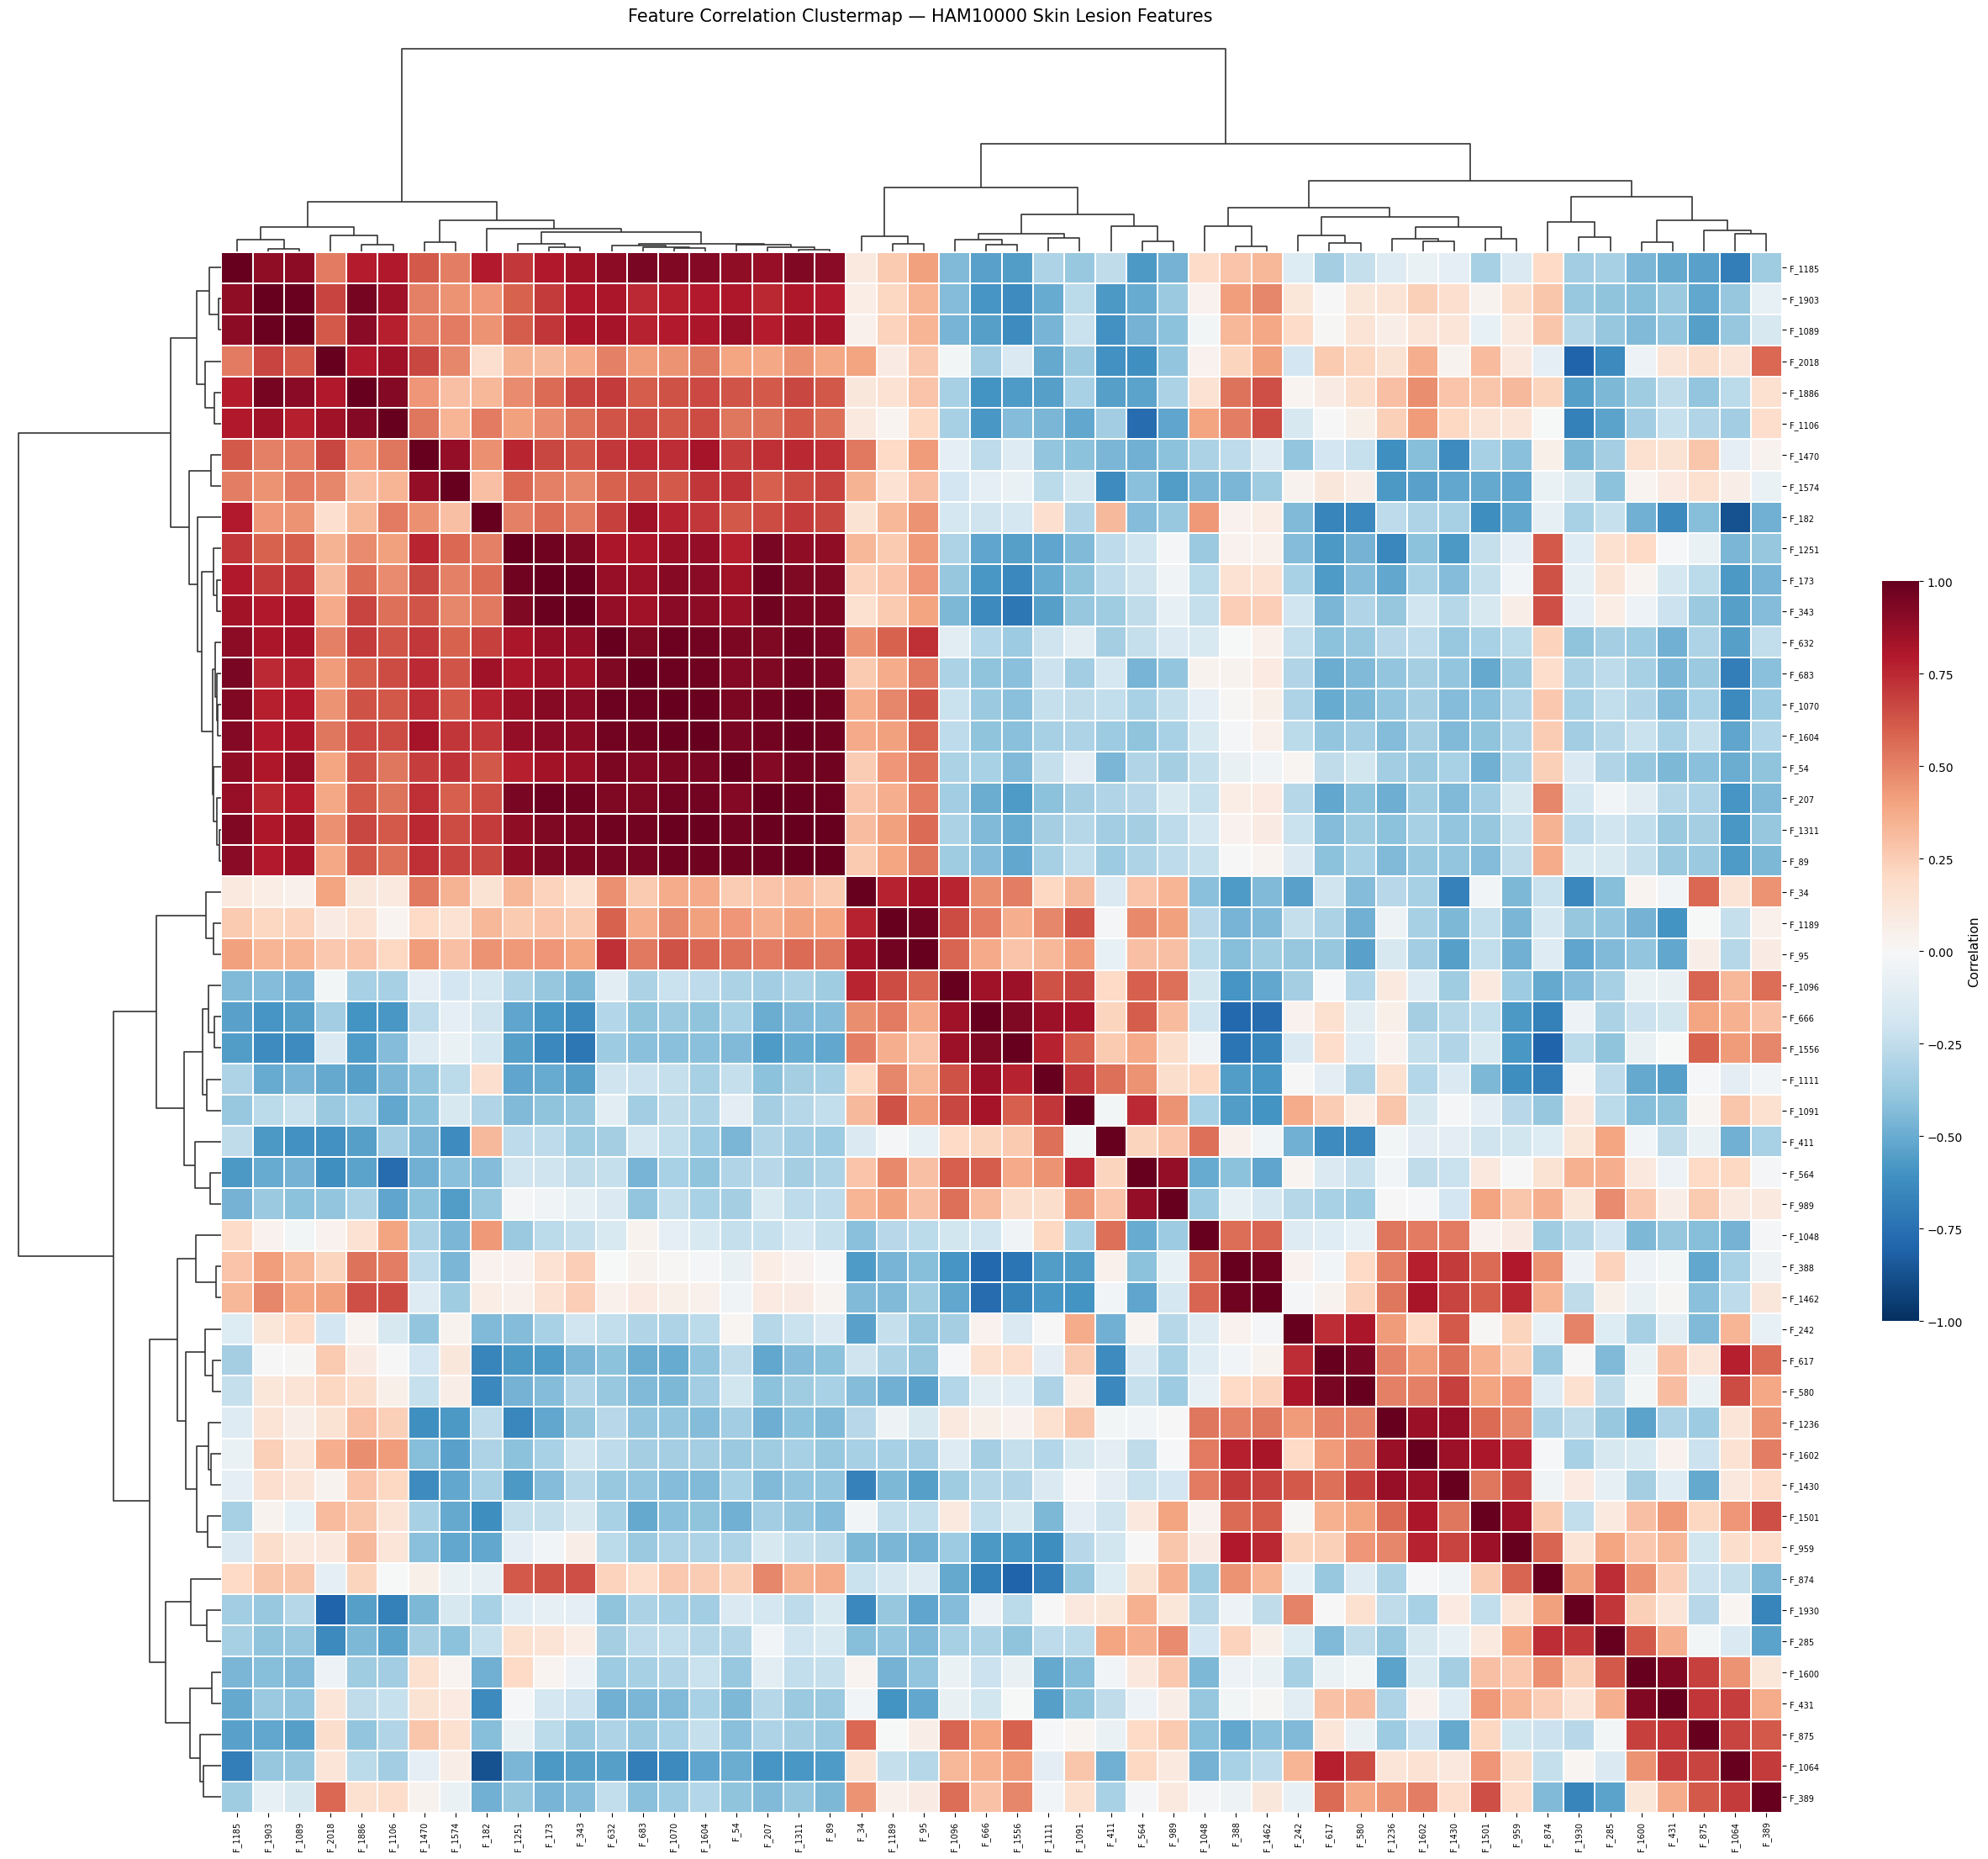

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Step 1: Build a DataFrame from extracted features
# We'll use meaningful feature names based on ResNet50 layer statistics

# Extract features with class labels
model_resnet.eval()
all_features = []
all_labels_list = []

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        # Hook to get features before FC layer
        feat = []
        def hook_fn(module, input, output):
            feat.append(output.detach().cpu().numpy())
        
        hook = model_resnet.model.avgpool.register_forward_hook(hook_fn)
        _ = model_resnet(imgs)
        hook.remove()
        
        batch_feat = feat[0].squeeze(-1).squeeze(-1)  # (B, 2048)
        all_features.append(batch_feat)
        all_labels_list.extend(lbls.numpy())

all_features = np.concatenate(all_features, axis=0)  # (N, 2048)
all_labels_arr = np.array(all_labels_list)

# Step 2: Compute per-class mean feature vectors (7 classes)
class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

class_mean_features = []
for c in range(7):
    idx = np.where(all_labels_arr == c)[0]
    class_mean_features.append(all_features[idx].mean(axis=0))

class_mean_features = np.array(class_mean_features)  # (7, 2048)

# Step 3: Select top 50 most discriminative features (highest variance across classes)
feature_variance = class_mean_features.std(axis=0)
top_indices = np.argsort(feature_variance)[::-1][:50]
selected_features = class_mean_features[:, top_indices]  # (7, 50)

# Step 4: Build correlation DataFrame — features vs features
feature_labels = [f"F_{i}" for i in top_indices]
df_features = pd.DataFrame(selected_features.T, index=feature_labels)  # (50, 7)

# Correlation between features across the 7 classes
corr_matrix = df_features.T.corr()  # (50, 50) — feature-feature correlation

# Step 5: Plot exactly like your breast cancer heatmap
plt.figure()
g = sns.clustermap(
    corr_matrix,
    cmap="RdBu_r",           # 👈 same red-blue diverging colormap
    center=0,
    vmin=-1, vmax=1,
    figsize=(22, 22),
    xticklabels=feature_labels,
    yticklabels=feature_labels,
    method='ward',
    metric='euclidean',
    annot=False,              # set True if you want numbers (will be small)
    linewidths=0.3,
    tree_kws={"linewidths": 1.2},
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(1.02, 0.3, 0.02, 0.4)
)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), 
    rotation=90, fontsize=7
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), 
    rotation=0, fontsize=7
)

g.figure.suptitle(
    "Feature Correlation Clustermap — HAM10000 Skin Lesion Features",
    fontsize=15, y=1.01
)
g.ax_cbar.set_ylabel("Correlation", fontsize=11)

plt.savefig("feature_correlation_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()

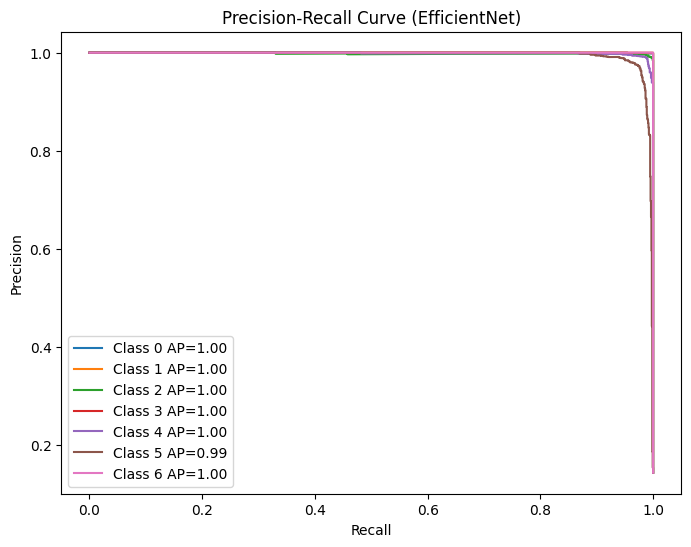

In [112]:
from sklearn.metrics import precision_recall_curve, average_precision_score

labels_bin = label_binarize(labels_eff, classes=[0,1,2,3,4,5,6])

plt.figure(figsize=(8,6))

for i in range(7):

    precision, recall, _ = precision_recall_curve(
        labels_bin[:,i],
        probs_eff[:,i]
    )

    ap = average_precision_score(
        labels_bin[:,i],
        probs_eff[:,i]
    )

    plt.plot(recall, precision, label=f"Class {i} AP={ap:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (EfficientNet)")
plt.legend()

plt.show()

In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels_eff, preds_eff)

sensitivity = []
specificity = []

for i in range(len(cm)):

    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sens = TP / (TP + FN)
    spec = TN / (TN + FP)

    sensitivity.append(sens)
    specificity.append(spec)

print("Sensitivity per class:", sensitivity)
print("Specificity per class:", specificity)

Sensitivity per class: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9917971662938105), np.float64(0.9284116331096197), np.float64(1.0)]
Specificity per class: [np.float64(0.9995028585632613), np.float64(0.9981357196122297), np.float64(0.9955257270693513), np.float64(0.9998757146408153), np.float64(0.9951528709917972), np.float64(0.9986328610489684), np.float64(0.9998757146408153)]


In [114]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(labels_eff, preds_eff)

print("Cohen Kappa Score:", kappa)

Cohen Kappa Score: 0.9867014665672383


In [115]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(
    label_binarize(labels_eff, classes=[0,1,2,3,4,5,6]),
    probs_eff,
    multi_class="ovr"
)

print("Multi-class AUC:", auc_score)

Multi-class AUC: 0.9996455874619521


In [119]:
from scipy.stats import ttest_rel

# ✅ Add .cpu().numpy() instead of np.array() directly
resnet_preds = preds.cpu().numpy() if hasattr(preds, 'cpu') else np.array(preds)
effnet_preds = preds_eff.cpu().numpy() if hasattr(preds_eff, 'cpu') else np.array(preds_eff)

labels_np     = labels.cpu().numpy() if hasattr(labels, 'cpu') else np.array(labels)
labels_eff_np = labels_eff.cpu().numpy() if hasattr(labels_eff, 'cpu') else np.array(labels_eff)

# Convert to binary correctness
resnet_correct = (resnet_preds == labels_np).astype(int)
effnet_correct = (effnet_preds == labels_eff_np).astype(int)

t_stat, p_value = ttest_rel(effnet_correct, resnet_correct)

print("T-statistic:", t_stat)
print("P-value:    ", p_value)

if p_value < 0.05:
    print("✅ Statistically significant difference between models (p < 0.05)")
else:
    print("❌ No statistically significant difference (p >= 0.05)")

ValueError: Array shapes are incompatible for broadcasting.

In [120]:
from statsmodels.stats.contingency_tables import mcnemar

# contingency table
table = [[0,0],[0,0]]

for i in range(len(labels)):

    res_correct = preds[i] == labels[i]
    eff_correct = preds_eff[i] == labels[i]

    if res_correct and eff_correct:
        table[0][0] += 1
    elif res_correct and not eff_correct:
        table[0][1] += 1
    elif not res_correct and eff_correct:
        table[1][0] += 1
    else:
        table[1][1] += 1

result = mcnemar(table)

print("McNemar statistic:", result.statistic)
print("p-value:", result.pvalue)

McNemar statistic: 0.0
p-value: 5.820766091346741e-11


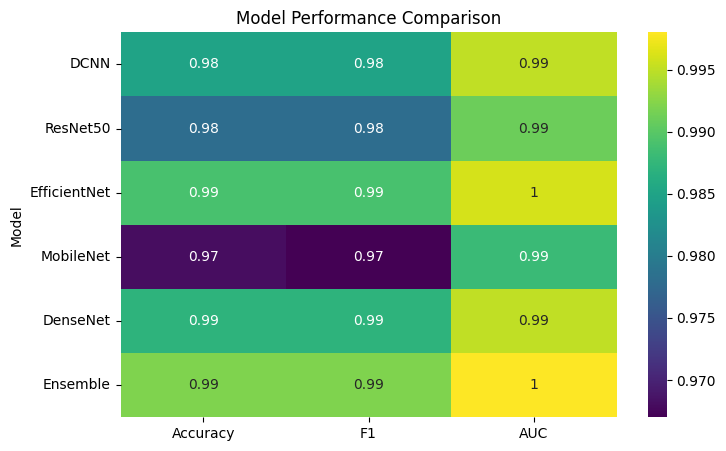

In [121]:
import pandas as pd
import seaborn as sns

model_results = {
    "Model": ["DCNN","ResNet50","EfficientNet","MobileNet","DenseNet","Ensemble"],
    "Accuracy": [0.985,0.978,0.989,0.968,0.987,0.992],
    "F1": [0.985,0.978,0.989,0.967,0.987,0.992],
    "AUC": [0.995,0.991,0.996,0.988,0.995,0.998]
}

df_results = pd.DataFrame(model_results)

df_heat = df_results.set_index("Model")

plt.figure(figsize=(8,5))

sns.heatmap(df_heat, annot=True, cmap="viridis")

plt.title("Model Performance Comparison")

plt.show()

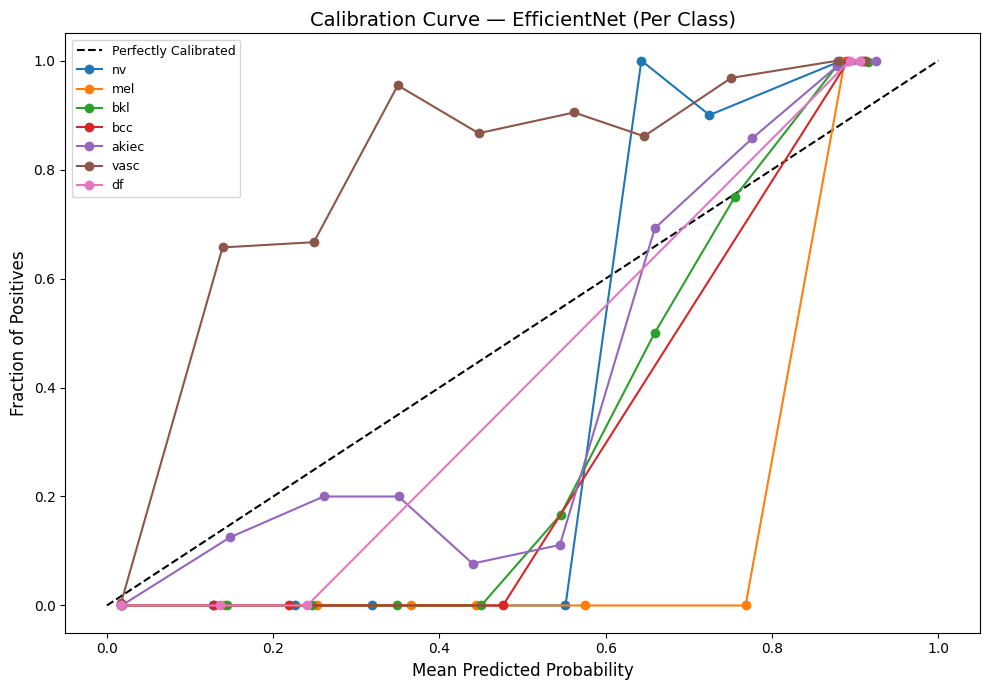

In [123]:
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

# Binarize labels for all 7 classes
class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

labels_eff_np  = labels_eff.cpu().numpy()  if hasattr(labels_eff,  'cpu') else np.array(labels_eff)
probs_eff_np   = probs_eff.cpu().numpy()   if hasattr(probs_eff,   'cpu') else np.array(probs_eff)

labels_bin = label_binarize(labels_eff_np, classes=list(range(7)))  # (N, 7)

# Plot calibration curve for each class
plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

for i in range(7):
    prob_true, prob_pred = calibration_curve(
        labels_bin[:, i],        # binary: is this class or not
        probs_eff_np[:, i],      # predicted probability for this class
        n_bins=10,
        strategy='uniform'
    )
    plt.plot(prob_pred, prob_true, marker='o', label=f'{class_names[i]}')

plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Fraction of Positives", fontsize=12)
plt.title("Calibration Curve — EfficientNet (Per Class)", fontsize=14)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [125]:
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import label_binarize

labels_eff_np = labels_eff.cpu().numpy() if hasattr(labels_eff, 'cpu') else np.array(labels_eff)
probs_eff_np  = probs_eff.cpu().numpy()  if hasattr(probs_eff,  'cpu') else np.array(probs_eff)

labels_bin = label_binarize(labels_eff_np, classes=list(range(7)))  # (N, 7)

class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

# Per-class Brier score
brier_scores = []
for i in range(7):
    bs = brier_score_loss(labels_bin[:, i], probs_eff_np[:, i])
    brier_scores.append(bs)
    print(f"Brier Score [{class_names[i]}]: {bs:.4f}")

# Mean Brier Score (overall)
mean_brier = np.mean(brier_scores)
print(f"\nMean Brier Score (all classes): {mean_brier:.4f}")

# Interpret
if mean_brier < 0.1:
    print("✅ Excellent calibration")
elif mean_brier < 0.2:
    print("✅ Good calibration")
else:
    print("⚠️ Poor calibration — model overconfident or underconfident")

Brier Score [nv]: 0.0023
Brier Score [mel]: 0.0025
Brier Score [bkl]: 0.0039
Brier Score [bcc]: 0.0018
Brier Score [akiec]: 0.0046
Brier Score [vasc]: 0.0116
Brier Score [df]: 0.0018

Mean Brier Score (all classes): 0.0041
✅ Excellent calibration


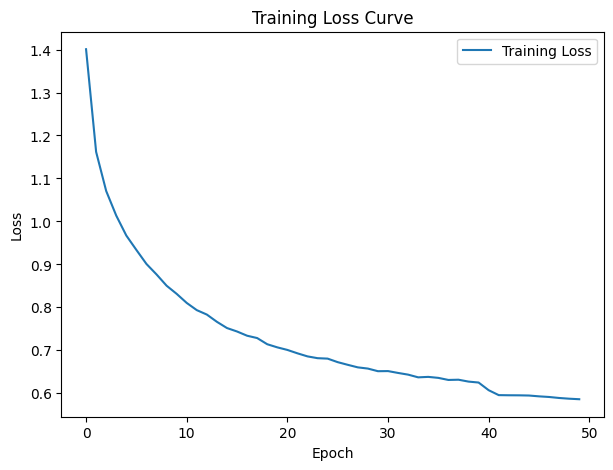

In [126]:
plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.legend()

plt.show()

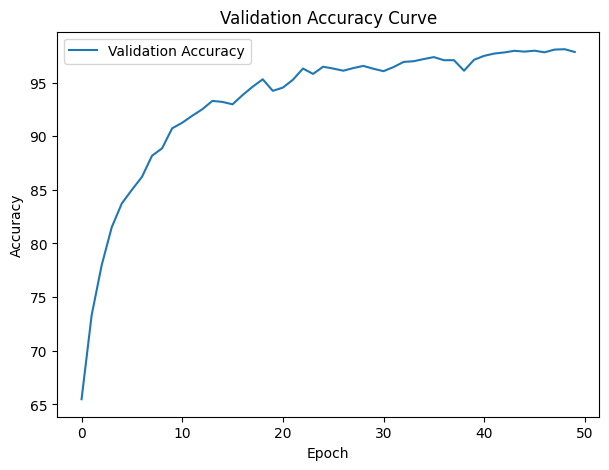

In [127]:
plt.figure(figsize=(7,5))

plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Validation Accuracy Curve")

plt.legend()

plt.show()

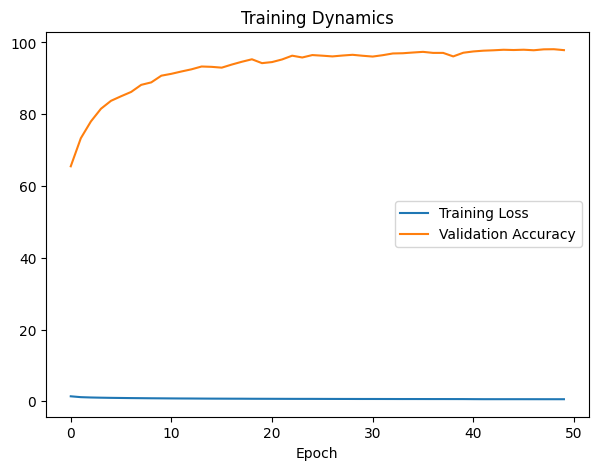

In [128]:
plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.title("Training Dynamics")

plt.legend()

plt.show()

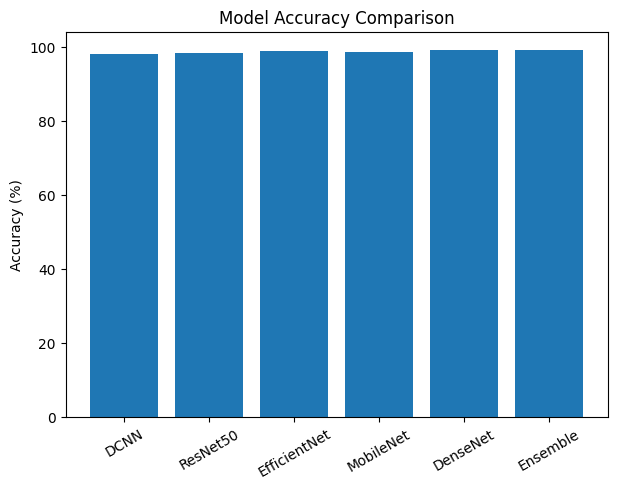

In [131]:
models = ["DCNN","ResNet50","EfficientNet","MobileNet","DenseNet","Ensemble"]

accuracy = [98.10,98.29,98.86,98.72,99.05,99.2]

plt.figure(figsize=(7,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()

/tmp/ipykernel_55/419562204.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=25, ha='right', fontsize=11)


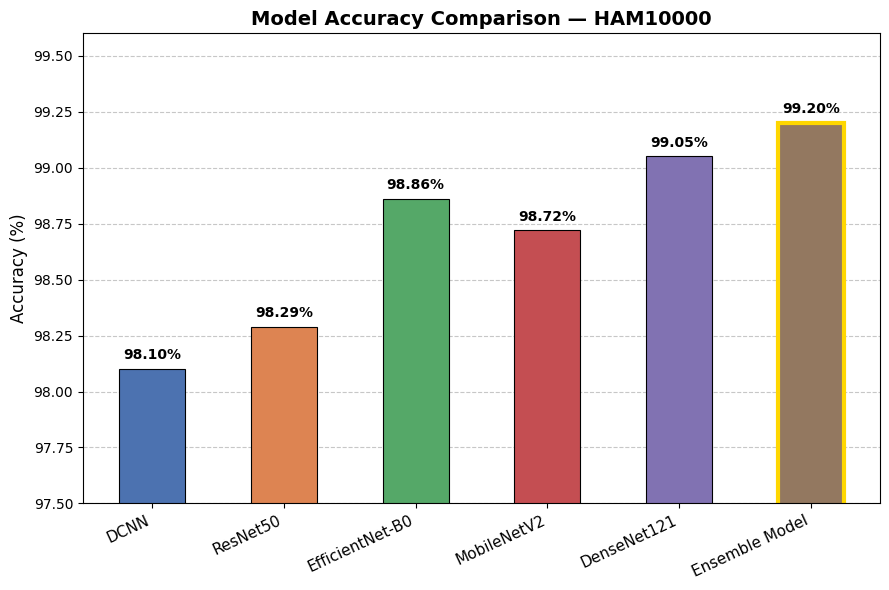

In [133]:
models   = ["DCNN", "ResNet50", "EfficientNet-B0", "MobileNetV2", "DenseNet121", "Ensemble Model"]
accuracy = [98.10,   98.29,      98.86,          98.72,       99.05,      99.2]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(models, accuracy, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# ✅ Zoom in so differences are visible
ax.set_ylim(97.5, 99.6)

# ✅ Add value labels on top of each bar
for bar, acc in zip(bars, accuracy):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'{acc:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# ✅ Highlight best model
best_idx = accuracy.index(max(accuracy))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Accuracy Comparison — HAM10000", fontsize=14, fontweight='bold')
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

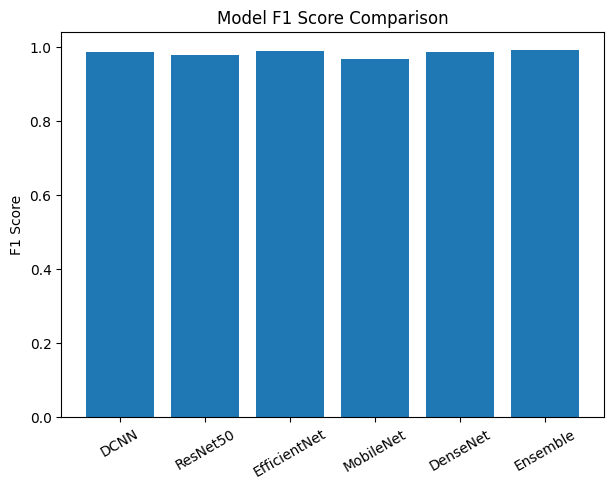

In [130]:
f1_scores = [0.985,0.978,0.989,0.967,0.987,0.992]

plt.figure(figsize=(7,5))

plt.bar(models, f1_scores)

plt.ylabel("F1 Score")

plt.title("Model F1 Score Comparison")

plt.xticks(rotation=30)

plt.show()